# **Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones**

# **M16:** Inventarios Forestales Nacionales, cálculo de biomasa y evaluación del estado de los bosques nativos

**Grupo 1:**
- Ahumada, Magalí

- Martín, Nicolás Eugenio

- Nedel, Agustina Itatí

### **Objetivo General**

Aplicar herramientas y métodos de ciencia de datos al análisis de los datos del Segundo Inventario Nacional de Bosques Nativos (INBN2) de Argentina, a través de un proceso progresivo que comprende la exploración, visualización, curación y modelado estadístico de variables dasométricas y espaciales, con el fin de caracterizar la estructura y el estado de los bosques nativos y generar conocimiento útil para la evaluación y gestión forestal sostenible.



## **TP1 - Práctico de análisis y visualización.**


Durante esta primera etapa, se buscará familiarizarse con el dataset, analizar con qué datos contamos, en cantidad y calidad: indagando no sólo el tipo de cada dato si no su naturaleza.
Para un mejor entendimiento de los datos en cada un a de las bases de datos les adjunto una descripción de las variables incluidas.
La tabla general “2INBN_Tabla_general_2021” posee datos a nivel de unidad de muestreo. Esto quiere decir que las variables numéricas continuas describen ciertas características del bosque encontrado en cada unidad de muestreo y se obtienen en base a cálculos específicos desde los datos medidos en cada individuo (árbol o arbusto) dentro de dicha parcela. Estas variables derivadas describen características del bosque junto con otras variables cualitativas determinadas en la unidad de muestreo (recomiendo usar el “header” de la tabla de datos donde se detalla cada variable).
La tabla donde se detallan los datos de cada individuo medido dentro de cada unidad de muestreo “data_individuos_pais_2021” posee los datos específicos de características de cada uno de los árboles. Esta es la información básica medida a campo con la cual se construyen los indicadores de la estructura del bosque (datos de la tabla general).
Las dos tablas poseen datos de coordenadas para poder utilizar los datos de manera espacial y la información se vincula en base a la variable “UM_ID_UM” que es el “key” único que no se repite para cada punto de muestreo.


In [123]:
import pandas as pd
import numpy as np
import seaborn as sns
import geopandas as gpd
import urllib.request
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

In [124]:
sns.set_context('talk')
pd.set_option('display.max_columns', 100)

In [125]:
# URLs de las bases del INBN2
url_tabla_2022 = 'https://raw.githubusercontent.com/AnibalCuchietti/Segundo-Inventario-Nacional-de-Bosques-Nativos-INBN2-/main/INF_ARG_UM_Tabla_general_2022.xlsx'
url_tabla_2021 = 'https://raw.githubusercontent.com/AnibalCuchietti/Segundo-Inventario-Nacional-de-Bosques-Nativos-INBN2-/main/2INBN_Tabla_general_2021.xlsx'
url_individuos = 'https://raw.githubusercontent.com/AnibalCuchietti/Segundo-Inventario-Nacional-de-Bosques-Nativos-INBN2-/main/data_individuos_pais_2021.csv'

### 1. Exploración del dataset

#### Diccionario de variables

In [126]:
df_header_raw = pd.read_excel(url_tabla_2021, sheet_name='Header')
col = df_header_raw.columns[0]

registros = []
for linea in df_header_raw[col].dropna():
    if ':' in linea:
        var, desc = linea.split(':', 1)
        var, desc = var.strip(), desc.strip()
        if ' ' in var or var.lower() == 'https' or desc == '':
            continue
        registros.append((var, desc))

diccionario_variables = pd.DataFrame(registros, columns=['variable', 'descripcion'])
print(f"Variables documentadas: {len(diccionario_variables)}")
diccionario_variables

Variables documentadas: 62


,variable,descripcion
0,UM_ID_UM,identificador único de cada unidad de muestreo
1,REGION_OFC,región forestal
2,SUBREG,subregión forestal
3,PROVINCIA,código del Instituto Nacional de Estadísticas ...
4,MEDIA_ALTURA_UM_EST,valor medio de la altura de los individuos leñ...
...,...,...
57,FORMAS_GRAMINEAS,presencia (TRUE) o ausencia (FALSE) de Gramín...
58,FORMAS_OTRAS,presencia (TRUE) o ausencia (FALSE) de Otras ...
59,Ley_N1_06,clasificación según la Leyenda Nivel 1 de la D...
60,Ley_N2_06,clasificación según la Leyenda Nivel 2 de la D...


#### Comparación entre tablas 2021 y 2022

In [127]:
df_um_2021 = pd.read_excel(url_tabla_2021, sheet_name='Tabla_general_2021')
df_um_2022 = pd.read_excel(url_tabla_2022, sheet_name='Tabla_general_2022 (2)')

print("Tabla general 2021:", df_um_2021.shape)
print("Tabla general 2022:", df_um_2022.shape)

Tabla general 2021: (3891, 62)
Tabla general 2022: (3891, 78)


#### ¿Son las mismas unidades de muestreo (UM)?

In [128]:

um_2021 = set(df_um_2021['UM_ID_UM'])
um_2022 = set(df_um_2022['UM_ID_UM'])

print("UM en 2021:", len(um_2021))
print("UM en 2022:", len(um_2022))
print("Intersección (UM en ambas):", len(um_2021 & um_2022))
print("UM solo en 2021:", len(um_2021 - um_2022))
print("UM solo en 2022:", len(um_2022 - um_2021))

UM en 2021: 3891
UM en 2022: 3891
Intersección (UM en ambas): 3891
UM solo en 2021: 0
UM solo en 2022: 0


#### ¿Qué columnas tiene una que no tenga la otra?

In [129]:
cols_2021 = set(df_um_2021.columns)
cols_2022 = set(df_um_2022.columns)

solo_2021 = sorted(cols_2021 - cols_2022)
solo_2022 = sorted(cols_2022 - cols_2021)

comparacion_cols = pd.DataFrame({
    'Solo en 2021': pd.Series(solo_2021),
    'Solo en 2022': pd.Series(solo_2022)
})

comparacion_cols

,Solo en 2021,Solo en 2022
0,NaN,BIOMASA_KG_HA
1,NaN,BIOMASA_TN_HA
2,NaN,CARBONO_KG_HA
3,NaN,CARBONO_TN_HA
4,NaN,CUENCA_FORESTAL
5,NaN,DATOS_REFERENCIA
6,NaN,DURACION_RELEVAMIENTO_SEGUNDOS
7,NaN,INSTRUMENTAL_ALTURAS
8,NaN,INSTRUMENTAL_DIAMETROS
9,NaN,JEFE_BRIGADA


#### ¿Los valores de las columnas que están en ambas son iguales?

In [130]:
# Para confirmar que 2022 es la misma tabla + columnas nuevas
cols_2021 = set(df_um_2021.columns)
cols_2022 = set(df_um_2022.columns)

cols_comunes = sorted((cols_2021 & cols_2022) - {'UM_ID_UM'})

comp = df_um_2021[['UM_ID_UM'] + cols_comunes].merge(
    df_um_2022[['UM_ID_UM'] + cols_comunes],
    on='UM_ID_UM', suffixes=('_2021', '_2022')
)

# Comparamos columna por columna cuántas filas difieren
diferencias = {}
for col in cols_comunes:
    c21, c22 = f"{col}_2021", f"{col}_2022"
    distintas = (comp[c21].astype(str) != comp[c22].astype(str)).sum()
    if distintas > 0:
        diferencias[col] = distintas

diferencias

# Tabla de diferencias entre 2021 y 2022, ordenada de mayor a menor
total_um = len(comp)

tabla_diferencias = (
    pd.Series(diferencias, name='filas_distintas')
    .rename_axis('columna')
    .reset_index()
)
tabla_diferencias['pct_distintas'] = (tabla_diferencias['filas_distintas'] / total_um * 100).round(1)
tabla_diferencias = tabla_diferencias.sort_values('pct_distintas', ascending=False).reset_index(drop=True)

tabla_diferencias

,columna,filas_distintas,pct_distintas
0,FORMAS_GRAMINEAS,3890,100.0
1,FORMAS_BRIOFITAS,3890,100.0
2,LONGITUD_GRILLA,3890,100.0
3,LATITUD_GRILLA,3890,100.0
4,FORMAS_EPIFITAS,3890,100.0
5,FORMAS_CACTACEAS,3890,100.0
6,FORMAS_HELECHOS,3890,100.0
7,FORMAS_OTRAS,3890,100.0
8,FORMAS_ORQUIDEAS,3890,100.0
9,FORMAS_LIANAS,3890,100.0


**Comparación de fuentes:**

A partir del diccionario de variables y de la comparación entre ambas versiones de la tabla general se concluye:

- **Mismo universo de unidades de muestreo (UM):** ambas tablas contienen las mismas 3.891 UM, no se trata de un relevamiento nuevo sino de la actualización sobre la misma base.

- **La versión 2022 agrega columnas nuevas que no están en la versión 2021**, como la variables de biomasa, carbono a nivel de parcela (`BIOMASA_TN_HA` `BIOMASA_KG_HA`, `CARBONO_TN_HA`, `CARBONO_KG_HA`), la cuenca forestal (`CUENCA_FORESTAL`), material caído (`dino/mediano`, `transectas norte y sur`) y datos del relevamiento (`brigada`, `jefe de brigada`, `duración`, `instrumental utilizado`) y observaciones de la UM.

- **Los valores de las columnas compartidas no son idénticos en ambas versiones:** al comparar fila por fila, la variables comunes con diferencias son: `FORMAS_GRAMINEAS`, `FORMAS_BRIOFITAS`, `LATITUD_GRILLA`, `LONGITUD_GRILLA`, `INCENDIOS_RASTROS`, `PASTOREO_PRESENCIA`, las variables `GANADO_` y `EROSION_ `presentan diferencias.

Esto indica que la tabla 2022 involucró una revisión de la mayoría de las variables existentes. En función de lo anterior, se utilizará la Tabla_general_2022 como fuente para todo el análisis de nivel de unidad de muestreo, evitando combinar valores de ambas versiones para no introducir inconsistencias.

### 1.2 EDA

Exploramos la información general de las variables, nulos, duplicados y estadísticas descriptivas.

In [131]:
# Filas y columnas de cada tabla
df_ind = pd.read_csv(url_individuos, sep=';', low_memory=False)
print("Tabla general (UM):", df_um_2022.shape)
print("Tabla individuos:", df_ind.shape)

Tabla general (UM): (3891, 78)
Tabla individuos: (101229, 31)


- Tabla general

In [132]:
# Información general de las variables - Tabla general (UM)
df_um_2022.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3891 entries, 0 to 3890
Data columns (total 78 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   UM_ID_UM                                3891 non-null   int64  
 1   REGION_OFC                              3890 non-null   object 
 2   SUBREG                                  3814 non-null   object 
 3   PROVINCIA                               3890 non-null   float64
 4   MEDIA_ALTURA_UM_EST                     3815 non-null   float64
 5   SUMA_DAP_X_UM                           3815 non-null   float64
 6   AREA_BASAL_UM_HA                        3815 non-null   float64
 7   VOL_M3_HA                               3795 non-null   float64
 8   BIOMASA_TN_HA                           3815 non-null   float64
 9   CARBONO_TN_HA                           3815 non-null   float64
 10  BIOMASA_KG_HA                           3815 non-null   floa

In [133]:
# Tipos de datos - Tabla general
df_um_2022.dtypes.value_counts()

,count
float64,50
object,23
int64,5


In [134]:
#Primeras filas - Tabla general
df_um_2022.head()

,UM_ID_UM,REGION_OFC,SUBREG,PROVINCIA,MEDIA_ALTURA_UM_EST,SUMA_DAP_X_UM,AREA_BASAL_UM_HA,VOL_M3_HA,BIOMASA_TN_HA,CARBONO_TN_HA,BIOMASA_KG_HA,CARBONO_KG_HA,CANTIDAD_IND_VIVOS_UM,CANTIDAD_IND_VIVOS_HA,PORCENTAJE_COB_3,PORCENTAJE_COB_7,PORCENTAJE_COB_TOTAL,PORCENTAJE_COB_ARBUSTIVA,PORCENTAJE_COB_INFERIOR,MEDIA_ALT_TOCONES,MEDIA_DAB_TOCONES,CANTIDAD_TOCONES_X_UM,CANTIDAD_TOCONES_X_HA,REGENERACION_UM,REGENERACION_HA,LONGITUD_GRILLA,LATITUD_GRILLA,LONGITUD_INSTALACION,LATITUD_INSTALACION,ALTITUD,PENDIENTE_CATEGORIA,EXPOSICION,OTBN_CATEGORIA,FECHA_UM_ANIO,FECHA_UM_MES,DURACION_RELEVAMIENTO_SEGUNDOS,JEFE_BRIGADA,NO_PERSONAS_BRIGADA,INSTRUMENTAL_DIAMETROS,INSTRUMENTAL_ALTURAS,DATOS_REFERENCIA,OBSERVACIONES_UM,TIPO_PAISAJE,SALINIDAD_PRESENCIA,INCENDIOS_RASTROS,PASTOREO_PRESENCIA,GANADO_BOVINO,GANADO_OVINO,GANADO_CAPRINO,GANADO_EQUINO,GANADO_OTRO,GANADO_OTRO_TIPO,EROSION_PRESENCIA,EROSION_FISICA_PRESENCIA,EROSION_EOLICA_PRESENCIA,EROSION_HIDRICA_PRESENCIA,MATERIAL_CAIDO_TRANSECTA_NORTE_FINO,MATERIAL_CAIDO_TRANSECTA_NORTE_MEDIANO,MATERIAL_CAIDO_TRANSECTA_SUR_FINO,MATERIAL_CAIDO_TRANSECTA_SUR_MEDIANO,PFNM_PRESENCIA_RESUMEN,PFNM_REGISTRO_1,PFNM_REGISTRO_2,PFNM_REGISTRO_3,PFNM_REGISTRO_4,PFNM_REGISTRO_5,FORMAS_HELECHOS,FORMAS_CACTACEAS,FORMAS_EPIFITAS,FORMAS_BRIOFITAS,FORMAS_LIANAS,FORMAS_ORQUIDEAS,FORMAS_GRAMINEAS,FORMAS_OTRAS,Ley_N1_06,Ley_N2_06,PRESENTA_IND_INVENTARIABLE,CUENCA_FORESTAL
0,6074195,MON,Monte,6.0,3.471429,0.914532,1.560872,1.728589,2.941308,1.411828,2941.307680,1411.827686,14.0,257.2,42.253521,0.0,42.253521,15.492958,100.000000,NaN,NaN,0,0,11,2200,-63273611.0,-39366332.0,-6.327364e+09,-3.936633e+09,41.0,sin_pendiente,NaN,sin_categoria,2020.0,1.0,7800.0,Emiliano Blanc,3.0,forcipula,vara,la parcela se encuentra dentro de el estableci...,el bosque se quemo en 2016. hay un proceso de ...,llano,ausencia,1.0,1.0,1.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,49.0,2.0,120.0,2.0,sin registro,sin registro,sin registro,sin registro,sin registro,sin registro,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,OTF,Bosque mixto,SI,NaN
1,6075190,ESP,Distrito del Caldén,6.0,5.450000,0.665793,2.928567,13.001816,10.310182,4.948887,10310.181760,4948.887243,2.0,49.3,35.211268,0.0,35.211268,23.943662,76.056338,NaN,NaN,0,0,2,400,-63156572.0,-38916172.0,-6.315658e+09,-3.891619e+09,26.0,sin_pendiente,NaN,sin_categoria,2020.0,1.0,2400.0,Emiliano Blanc,3.0,forcipula,vara,la parcela se encuentra a 5 km de juan costue ...,pasa un camino por la parcela - entraron muy ...,duna,ausencia,1.0,1.0,1.0,0.0,0.0,0.0,0.0,NaN,1.0,1.0,1.0,0.0,73.0,0.0,54.0,0.0,sin registro,sin registro,sin registro,sin registro,sin registro,sin registro,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,TF,Bosques de caldén abierto con arbustos,SI,NaN
2,6076186,ESP,Distrito del Caldén,6.0,3.897143,4.097999,6.866252,44.521998,13.078647,6.277750,13078.646740,6277.750435,35.0,877.4,36.619718,0.0,36.619718,100.000000,0.000000,NaN,NaN,0,0,54,10800,-63041063.0,-38555943.0,-6.304106e+09,-3.855594e+09,14.0,sin_pendiente,NaN,sin_categoria,2020.0,1.0,6000.0,Emiliano Blanc,3.0,forcipula,vara,de la rn 35 hay que tomar un camino de tierra ...,monte con abundantes renovales de chanar,llano,ausencia,0.0,1.0,1.0,0.0,0.0,0.0,0.0,NaN,1.0,1.0,0.0,0.0,63.0,0.0,105.0,5.0,Condalia microphylla_Lycium chilense,Condalia microphylla,Lycium chilense,sin registro,sin registro,sin registro,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,TF,Bosques de caldén abierto con arbustos,SI,NaN
3,6076194,ESP,Distrito del Caldén,6.0,3.871429,0.757000,1.053149,1.634049,1.986120,0.953337,1986.119635,953.337425,7.0,157.9,4.225352,0.0,4.225352,43.661972,83.098592,NaN,NaN,0,0,0,0,-6304148.0,-39276574.0,-6.304150e+05,-3.927656e+09,32.0,sin_pendiente,NaN,sin_categoria,2020.0,1.0,2700.0,Emiliano Blanc,3.0,forcipula,vara,"hay que entrar por la estancia ""el puma"" - at...",se observan signos de un incendio grande hace ...,llano,ausencia,1.0,1.0,1.0,0.0,0.0,0.0,0.0,NaN,1.0,1.0,0.0,0.0,27.0,0.0,31.0,0.0,sin registro,sin registro,sin registro,sin registro,sin registro,sin registro,0.0,0.0,0.

Cada fila representa una Unidad de Muestreo (UM), es decir una parcela de bosque relevada

In [135]:
# Valores faltantes por columna,  tabla general
missing_um = pd.DataFrame({
    'Faltantes': df_um_2022.isnull().sum(),
    'Porcentaje (%)': (df_um_2022.isnull().mean() * 100).round(2)
}).sort_values('Porcentaje (%)', ascending=False)

print(missing_um[missing_um['Faltantes'] > 0])

                   Faltantes  Porcentaje (%)
GANADO_OTRO_TIPO        3797           97.58
CUENCA_FORESTAL         3434           88.25
EXPOSICION              3367           86.53
Ley_N2_06               2878           73.97
MEDIA_DAB_TOCONES       2837           72.91
...                      ...             ...
PFNM_REGISTRO_3            1            0.03
PFNM_REGISTRO_4            1            0.03
PFNM_REGISTRO_5            1            0.03
FORMAS_ORQUIDEAS           1            0.03
FORMAS_GRAMINEAS           1            0.03

[72 rows x 2 columns]


In [136]:
# Análisis de duplicados - Tabla general
print("Filas completamente duplicadas:", df_um_2022.duplicated().sum())
print("UM_ID_UM duplicados:", df_um_2022['UM_ID_UM'].duplicated().sum())

Filas completamente duplicadas: 0
UM_ID_UM duplicados: 0


In [137]:
# Estadísticas descriptivas - Tabla general (solo variables numéricas)
df_um_2022.describe()

,UM_ID_UM,PROVINCIA,MEDIA_ALTURA_UM_EST,SUMA_DAP_X_UM,AREA_BASAL_UM_HA,VOL_M3_HA,BIOMASA_TN_HA,CARBONO_TN_HA,BIOMASA_KG_HA,CARBONO_KG_HA,CANTIDAD_IND_VIVOS_UM,CANTIDAD_IND_VIVOS_HA,PORCENTAJE_COB_3,PORCENTAJE_COB_7,PORCENTAJE_COB_TOTAL,PORCENTAJE_COB_ARBUSTIVA,PORCENTAJE_COB_INFERIOR,MEDIA_ALT_TOCONES,MEDIA_DAB_TOCONES,CANTIDAD_TOCONES_X_UM,CANTIDAD_TOCONES_X_HA,REGENERACION_UM,REGENERACION_HA,LONGITUD_GRILLA,LATITUD_GRILLA,LONGITUD_INSTALACION,LATITUD_INSTALACION,ALTITUD,FECHA_UM_ANIO,FECHA_UM_MES,DURACION_RELEVAMIENTO_SEGUNDOS,NO_PERSONAS_BRIGADA,INCENDIOS_RASTROS,PASTOREO_PRESENCIA,GANADO_BOVINO,GANADO_OVINO,GANADO_CAPRINO,GANADO_EQUINO,GANADO_OTRO,EROSION_PRESENCIA,EROSION_FISICA_PRESENCIA,EROSION_EOLICA_PRESENCIA,EROSION_HIDRICA_PRESENCIA,MATERIAL_CAIDO_TRANSECTA_NORTE_FINO,MATERIAL_CAIDO_TRANSECTA_NORTE_MEDIANO,MATERIAL_CAIDO_TRANSECTA_SUR_FINO,MATERIAL_CAIDO_TRANSECTA_SUR_MEDIANO,FORMAS_HELECHOS,FORMAS_CACTACEAS,FORMAS_EPIFITAS,FORMAS_BRIOFITAS,FORMAS_LIANAS,FORMAS_ORQUIDEAS,FORMAS_GRAMINEAS,FORMAS_OTRAS
count,3.891000e+03,3890.000000,3815.000000,3815.000000,3815.000000,3795.000000,3815.000000,3815.000000,3.815000e+03,3815.000000,3815.000000,3815.000000,3810.000000,3808.000000,3811.000000,3808.000000,3804.000000,1054.000000,1054.000000,3891.000000,3891.000000,3891.000000,3891.000000,3.890000e+03,3.890000e+03,3.890000e+03,3.890000e+03,3844.000000,3887.000000,3890.000000,3872.000000,3890.000000,3884.000000,3886.000000,2558.000000,2485.000000,2486.000000,2493.000000,2503.000000,3886.000000,2506.000000,2483.000000,2498.000000,2901.000000,2901.000000,2902.000000,2896.000000,3890.000000,3890.000000,3890.000000,3890.000000,3890.000000,3890.000000,3890.000000,3890.000000
mean,5.324471e+07,53.191774,7.333214,4.901103,11.935808,73.132790,61.861052,29.693305,6.186105e+04,29693.305149,26.430406,461.693132,40.683524,31.830394,60.753711,47.767043,43.527902,29.662143,27.848507,0.797995,7.979954,16.611668,3322.333590,-5.714168e+07,-2.551430e+07,-5.503293e+09,-2.451718e+09,347.636576,2018.151531,6.820308,6486.554752,2.993573,0.129248,0.682964,0.698593,0.029779,0.104183,0.218211,0.037555,0.416881,0.260974,0.052356,0.236990,59.736987,5.391934,55.290834,5.123964,0.185604,0.462211,0.677378,0.457069,0.309769,0.132648,0.437275,0.158869
std,2.535924e+07,25.327898,3.430465,3.328717,11.608277,105.136065,77.247638,37.078866,7.724764e+04,37078.866053,16.428128,315.826969,30.483882,31.541097,31.438996,35.635492,40.725661,21.209625,14.891579,2.318542,23.185418,15.016171,3003.234298,1.773394e+07,9.500475e+06,2.127121e+09,1.108812e+09,385.369281,1.073442,3.641826,3599.840708,0.847734,0.335518,0.465381,0.458959,0.170010,0.305560,0.413114,0.190155,0.493106,0.439253,0.222789,0.425321,160.559408,10.624068,139.804175,10.421787,0.388837,0.498634,0.467540,0.498218,0.462458,0.339237,0.496114,0.365601
min,6.074195e+06,6.000000,1.545455,0.000000,0.080118,0.224623,0.086656,0.041595,8.665625e+01,41.595002,1.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.100000,2.400000,0.000000,0.000000,0.000000,0.000000,-7.327566e+07,-5.496764e+07,-7.327567e+09,-5.496764e+09,0.000000,2015.000000,1.000000,780.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.011510e+07,30.000000,5.381751,2.578836,5.117254,21.423259,19.752173,9.481043,1.975217e+04,9481.042889,15.000000,228.600000,15.492958,0.000000,36.619718,12.676056,0.000000,15.000000,18.000000,0.000000,0.000000,6.000000,1200.000000,-6.478946e+07,-2.916690e+07,-6.473844e+09,-2.926326e+09,112.000000,2017.000000,3.000000,4080.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5.416405e+07,54.000000,6.396154,4.312062,8.841196,43.695902,40.486165,19.433359,4.048617e+0

- Tabla individuos

In [138]:
# Información general de las variables - Tabla individuos
df_ind.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101229 entries, 0 to 101228
Data columns (total 31 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   UM_ID_UM                    101229 non-null  int64  
 1   NO_INDIV                    101229 non-null  int64  
 2   PARCELA_CONCENTRICA         101229 non-null  object 
 3   ESPECIE_CORREGIDA           101229 non-null  object 
 4   REGION_OFC                  101229 non-null  object 
 5   SUBREG                      96093 non-null   object 
 6   ESTADO_INDIV                101229 non-null  object 
 7   ALTURA_TOTAL_M              101226 non-null  float64
 8   PROVINCIA                   101229 non-null  int64  
 9   COORDENADAS_GPS_LATITUDE2   101229 non-null  float64
 10  COORDENADAS_GPS_LONGITUDE2  101229 non-null  float64
 11  DAP_FINAL_M                 101229 non-null  float64
 12  ALTURA_TOTAL_EST            101229 non-null  float64
 13  VOL_M3        

In [139]:
# Tipos de datos - Tabla individuos
df_ind.dtypes.value_counts()

,count
float64,20
object,8
int64,3


In [140]:
#Primeras filas - Tabla individuos
df_ind.head()

,UM_ID_UM,NO_INDIV,PARCELA_CONCENTRICA,ESPECIE_CORREGIDA,REGION_OFC,SUBREG,ESTADO_INDIV,ALTURA_TOTAL_M,PROVINCIA,COORDENADAS_GPS_LATITUDE2,COORDENADAS_GPS_LONGITUDE2,DAP_FINAL_M,ALTURA_TOTAL_EST,VOL_M3,VOL_M3_HA,DAP_CM,AREABASAL_CM2,AREABASAL_M2,DENSIDAD_MADERA,BIOMASA_KG,CARBONO_KG,CLASE_DIAM,BIOMASA_TN_HA,CARBONO_TN_HA,MEDIA_DIAM_COPA,DAB_FINAL_M,DIAMETRO_COPA_1,DIAMETRO_COPA_2,DAB_CM,Ley_N1_06,Ley_N2_06
0,6074195,1,A,Prosopis alpataco,MON,Monte,2,4.2,6,-39.366333,-63.273639,0.118381,4.2,0.027448,0.274485,11.838074,110.065699,0.011007,0.792,27.071153,12.994154,[10-20),0.270712,0.129942,0.0,0.0,NaN,NaN,NaN,OTF,Bosque mixto
1,6074195,3,A,UNLISTED,MON,Monte,3,4.8,6,-39.366333,-63.273639,0.101607,4.8,0.014682,0.146822,10.160709,81.084506,0.008108,0.715,20.712136,9.941825,[10-20),0.207121,0.099418,0.0,0.0,NaN,NaN,NaN,OTF,Bosque mixto
2,6074195,8,A,UNLISTED,MON,Monte,4,4.4,6,-39.366333,-63.273639,0.082219,4.4,0.012296,0.122964,8.221922,53.092916,0.005309,0.715,12.585068,6.040833,[5-10),0.125851,0.060408,0.0,0.0,NaN,NaN,NaN,OTF,Bosque mixto
3,6074195,9,A,UNLISTED,MON,Monte,2,3.5,6,-39.366333,-63.273639,0.077987,3.5,0.011824,0.118236,7.798718,47.767916,0.004777,0.715,9.079407,4.358115,[5-10),0.090794,0.043581,0.0,0.0,NaN,NaN,NaN,OTF,Bosque mixto
4,6074195,25,A,UNLISTED,MON,Monte,3,3.7,6,-39.366333,-63.273639,0.121655,3.7,0.017004,0.170042,12.165525,116.238928,0.011624,0.715,22.832742,10.959716,[10-20),0.228327,0.109597,0.0,0.0,NaN,NaN,NaN,OTF,Bosque mixto


Cada fila representa un individuo (árbol/arbusto) medido dentro de una UM.

Varios individuos comparten el mismo UM_ID_UM (la parcela donde fueron medidos).

In [141]:
# Valores faltantes por columna,  tabla individuos
missing_ind = pd.DataFrame({
    'Faltantes': df_ind.isnull().sum(),
    'Porcentaje (%)': (df_ind.isnull().mean() * 100).round(2)
}).sort_values('Porcentaje (%)', ascending=False)

print(missing_ind[missing_ind['Faltantes'] > 0])

                 Faltantes  Porcentaje (%)
DIAMETRO_COPA_1     100248           99.03
DAB_CM              100248           99.03
DIAMETRO_COPA_2     100248           99.03
MEDIA_DIAM_COPA      99245           98.04
DAB_FINAL_M          99245           98.04
Ley_N2_06            77534           76.59
SUBREG                5136            5.07
VOL_M3_HA              987            0.98
VOL_M3                 987            0.98
ALTURA_TOTAL_M           3            0.00


In [142]:
#Análisis de duplicados - Tabla individuos
print("Filas completamente duplicadas:", df_ind.duplicated().sum())

# Se espera que la combinaciónUM_ID_UM + NO_INDIV sea única
print("UM_ID_UM duplicados (esperable):", df_ind['UM_ID_UM'].duplicated().sum())

print("Combinación UM_ID_UM + PARCELA_CONCENTRICA + NO_INDIV duplicada:",
      df_ind.duplicated(subset=['UM_ID_UM', 'PARCELA_CONCENTRICA', 'NO_INDIV']).sum())

n_duplicados_um_indiv = df_ind.duplicated(subset=['UM_ID_UM', 'NO_INDIV']).sum()
print("Duplicados con clave UM_ID_UM + NO_INDIV:", n_duplicados_um_indiv)

ejemplo = df_ind[df_ind.duplicated(subset=['UM_ID_UM', 'NO_INDIV'], keep=False)].sort_values(['UM_ID_UM', 'NO_INDIV'])
ejemplo[['UM_ID_UM', 'NO_INDIV', 'PARCELA_CONCENTRICA', 'ESPECIE_CORREGIDA']].head(10)


Filas completamente duplicadas: 0
UM_ID_UM duplicados (esperable): 97414
Combinación UM_ID_UM + PARCELA_CONCENTRICA + NO_INDIV duplicada: 0
Duplicados con clave UM_ID_UM + NO_INDIV: 6911


,UM_ID_UM,NO_INDIV,PARCELA_CONCENTRICA,ESPECIE_CORREGIDA
6965,22073042,1,A,Schinopsis lorentzii
6966,22073042,1,B,Senegalia gilliesii
6978,22073042,2,A,Schinopsis lorentzii
6979,22073042,2,B,Senegalia gilliesii
6981,22073042,3,A,Parkinsonia praecox
6982,22073042,3,B,Sarcomphalus mistol
6983,22073042,4,A,Schinopsis lorentzii
6984,22073042,4,B,Senegalia praecox
6985,22073042,5,A,Sarcomphalus mistol
6986,22073042,5,B,Senegalia gilliesii


Al validar duplicados con la clave `UM_ID_UM + NO_INDIV` se detectaron 6.911 casos. Al inspeccionarlos, se observó que `NO_INDIV` se numera dentro de cada parcela concéntrica (`PARCELA_CONCENTRICA`: A, B, etc.) y no a nivel de toda la UM — por ejemplo, el individuo N°1 de la parcela A y el N°1 de la parcela B son árboles distintos dentro de la misma UM. Al incorporar `PARCELA_CONCENTRICA` a la clave, los duplicados desaparecen (0 casos).

Como no se trata de un problema de calidad de datos, sino de una clave de identificación de individuo mal definida en nuestro análisis inicial, no se elimina ninguna fila por este motivo.

In [143]:
# Estadísticas descriptivas - Tabla individuos
df_ind.describe()

,UM_ID_UM,NO_INDIV,ALTURA_TOTAL_M,PROVINCIA,COORDENADAS_GPS_LATITUDE2,COORDENADAS_GPS_LONGITUDE2,DAP_FINAL_M,ALTURA_TOTAL_EST,VOL_M3,VOL_M3_HA,DAP_CM,AREABASAL_CM2,AREABASAL_M2,DENSIDAD_MADERA,BIOMASA_KG,CARBONO_KG,BIOMASA_TN_HA,CARBONO_TN_HA,MEDIA_DIAM_COPA,DAB_FINAL_M,DIAMETRO_COPA_1,DIAMETRO_COPA_2,DAB_CM
count,1.012290e+05,101229.000000,101226.000000,101229.000000,101229.000000,101229.000000,101229.000000,101229.000000,100242.000000,100242.000000,101229.000000,101229.000000,101229.000000,101229.000000,101229.000000,101229.000000,101229.000000,101229.000000,1984.000000,1984.000000,981.000000,981.000000,981.000000
mean,5.020281e+07,19.258612,7.376776,50.120953,-28.027521,-62.574503,0.184707,7.376667,0.242747,2.745570,18.470701,178.131593,0.017813,0.779501,217.863441,104.574452,2.348895,1.127469,1.418916,0.051377,2.804720,2.354465,11.906524
std,2.527618e+07,19.989189,4.085350,25.286368,5.936692,3.372056,0.128514,4.069119,0.710107,7.093462,12.851366,696.592716,0.069659,0.172249,637.652339,306.073123,6.365637,3.055506,1.686227,0.061049,1.317603,1.974742,7.121753
min,6.074195e+06,1.000000,0.100000,6.000000,-54.967639,-73.275667,0.000000,0.800000,0.000101,0.003967,0.000000,0.196350,0.000020,0.165000,0.152763,0.073326,0.006004,0.002882,0.000000,0.000000,0.000000,0.000000,5.000000
25%,2.600624e+07,6.000000,4.700000,26.000000,-28.879444,-64.470778,0.105000,4.700000,0.033062,0.606992,10.500000,0.950332,0.000095,0.655000,24.433208,11.727940,0.390978,0.187669,0.000000,0.000000,1.800000,1.500000,6.900000
50%,4.603809e+07,14.000000,6.300000,46.000000,-26.180833,-62.542389,0.150013,6.300000,0.083845,1.142415,15.001333,2.460574,0.000246,0.800000,66.501026,31.920493,0.839209,0.402820,1.100000,0.000000,2.500000,2.100000,10.600000
75%,6.608203e+07,26.000000,8.700000,66.000000,-24.730917,-60.193500,0.230000,8.700000,0.207861,2.572194,23.000000,21.194833,0.002119,0.875000,200.564844,96.271125,2.222324,1.066715,2.550000,0.101000,3.500000,3.000000,13.900000
max,9.406237e+07,409.000000,58.000000,94.000000,-22.046333,-53.699944,2.650000,44.000000,54.232673,542.326727,265.000000,55154.586020,5.515459,1.220000,48209.278870,23140.453860,482.092789,231.404539,29.400000,0.620000,9.500000,53.000000,65.100000


### 1.3. Estudio de desbalance

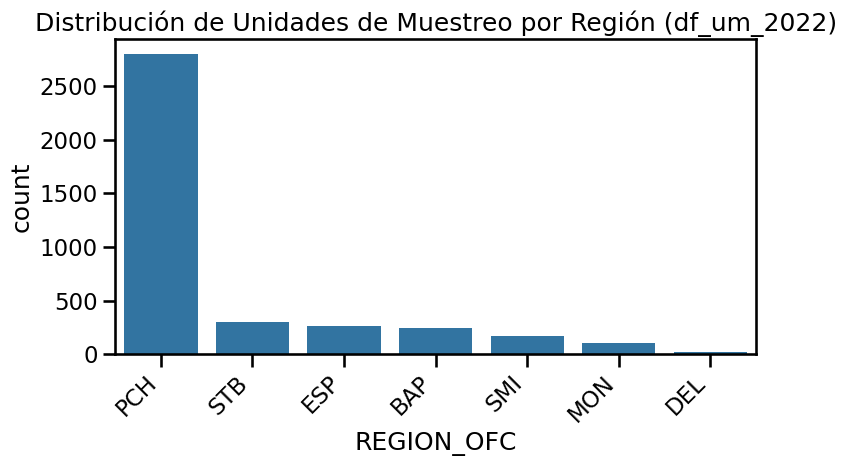

In [144]:
# Estudio de desbalance por región - Tabla general (nivel UM)
plt.figure(figsize=(8,5))
sns.countplot(data=df_um_2022, x='REGION_OFC', order=df_um_2022['REGION_OFC'].value_counts().index)
plt.title('Distribución de Unidades de Muestreo por Región (df_um_2022)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

El Parque Chaqueño (PCH) concentra el 72% de las Unidades de Muestreo. Le siguen, Bosque Tucumano-Boliviano (STB), Espinal (ESP) y Bosque Andino Patagónico (BAP), cada una entre el 6% y el 8% del total.

En el otro extremo, Delta e Islas (DEL) representa el 0.5% de las UM (18 parcelas).

Este desbalance responde a que el diseño del inventario es proporcional a la superficie real de bosque nativo de cada región, y el Parque Chaqueño concentra la mayor superficie boscosa del país.

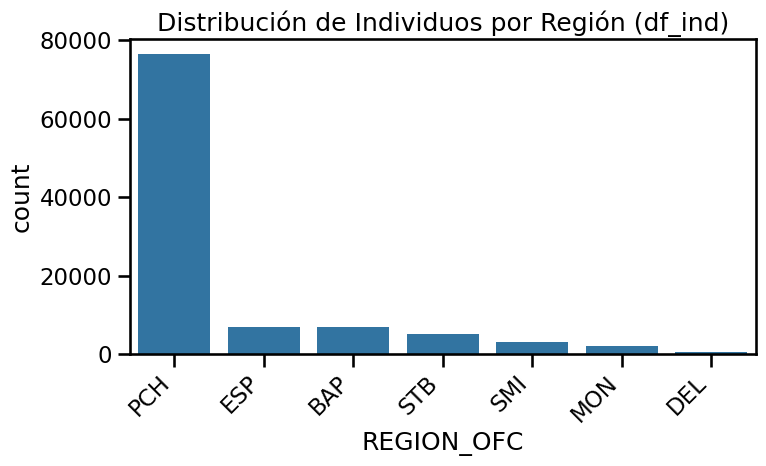

In [145]:
# Estudio de desbalance por región - Tabla individuos (nivel árbol)
plt.figure(figsize=(8,5))
sns.countplot(data=df_ind, x='REGION_OFC', order=df_ind['REGION_OFC'].value_counts().index)
plt.title('Distribución de Individuos por Región (df_ind)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

El desbalance se profundiza a nivel de individuo: PCH pasa de concentrar el 72% de las UM al 76% de los individuos medidos (76.486 de 101.229). El orden de las regiones también cambia respecto del gráfico anterior predominando ESP y BAP.

Esto sugiere que la densidad de individuos por parcela no es uniforme entre regiones, algunas regiones tienen parcelas con pocos individuos por UM, mientras que otras concentran más árboles por parcela relevada.

Este punto es relevante para el análisis que sigue, cualquier comparación entre regiones que use conteos absolutos en vez de promedios o densidades por hectárea va a estar sesgada por lo que conviene priorizar variables normalizadas (por ejemplo, "por hectárea") al comparar regiones.

### 1.4. Correlación entre variables

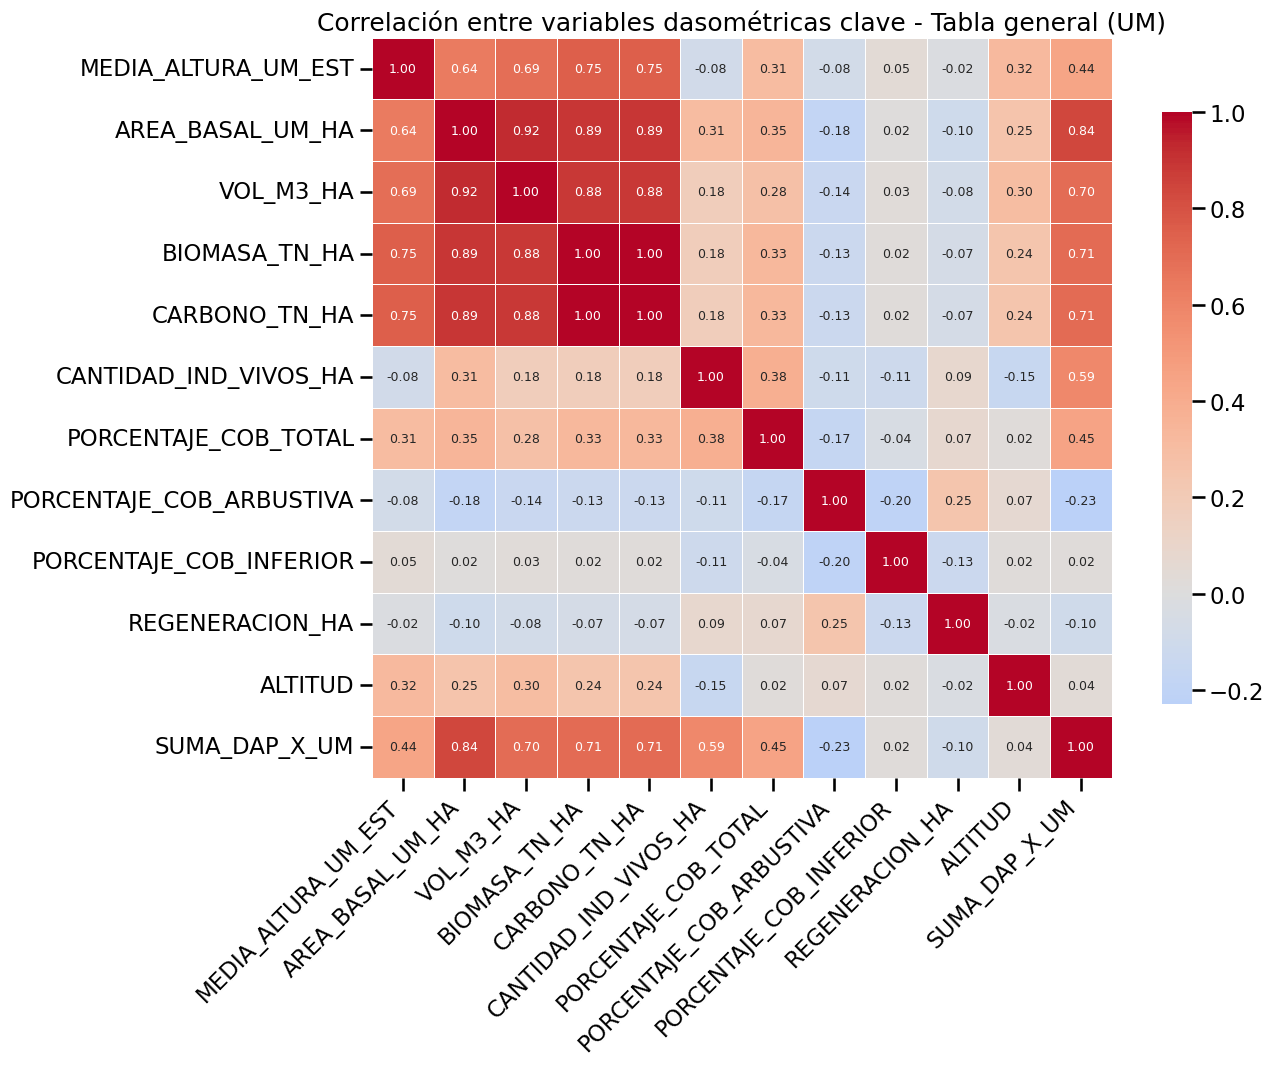

In [146]:
# Correlación entre variables numéricas dasométricas - Tabla general
vars_clave_um = [
    'MEDIA_ALTURA_UM_EST', 'AREA_BASAL_UM_HA', 'VOL_M3_HA',
    'BIOMASA_TN_HA', 'CARBONO_TN_HA', 'CANTIDAD_IND_VIVOS_HA',
    'PORCENTAJE_COB_TOTAL', 'PORCENTAJE_COB_ARBUSTIVA', 'PORCENTAJE_COB_INFERIOR',
    'REGENERACION_HA', 'ALTITUD', 'SUMA_DAP_X_UM'
]

corr_um = df_um_2022[vars_clave_um].corr()

plt.figure(figsize=(14, 11))
sns.heatmap(corr_um, cmap='coolwarm', center=0, annot=True, fmt='.2f',
            annot_kws={'size': 9}, linewidths=0.5, square=True,
            cbar_kws={'shrink': 0.8})
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title('Correlación entre variables dasométricas clave - Tabla general (UM)')
plt.tight_layout()
plt.show()

Las variables estructurales (altura, área basal, volumen, biomasa, carbono, suma de DAP) correlacionan fuertemente entre sí (0.64–0.92), algo esperable ya que todas describen el desarrollo del rodal. BIOMASA_TN_HA y CARBONO_TN_HA correlacionan en 1.00 porque el carbono se calcula como fracción fija de la biomasa, no es una medición independiente.

En cambio, PORCENTAJE_COB_ARBUSTIVA y REGENERACION_HA se despegan del resto (correlaciones cercanas a 0 o negativas), lo que indica que capturan una dimensión distinta del bosque.

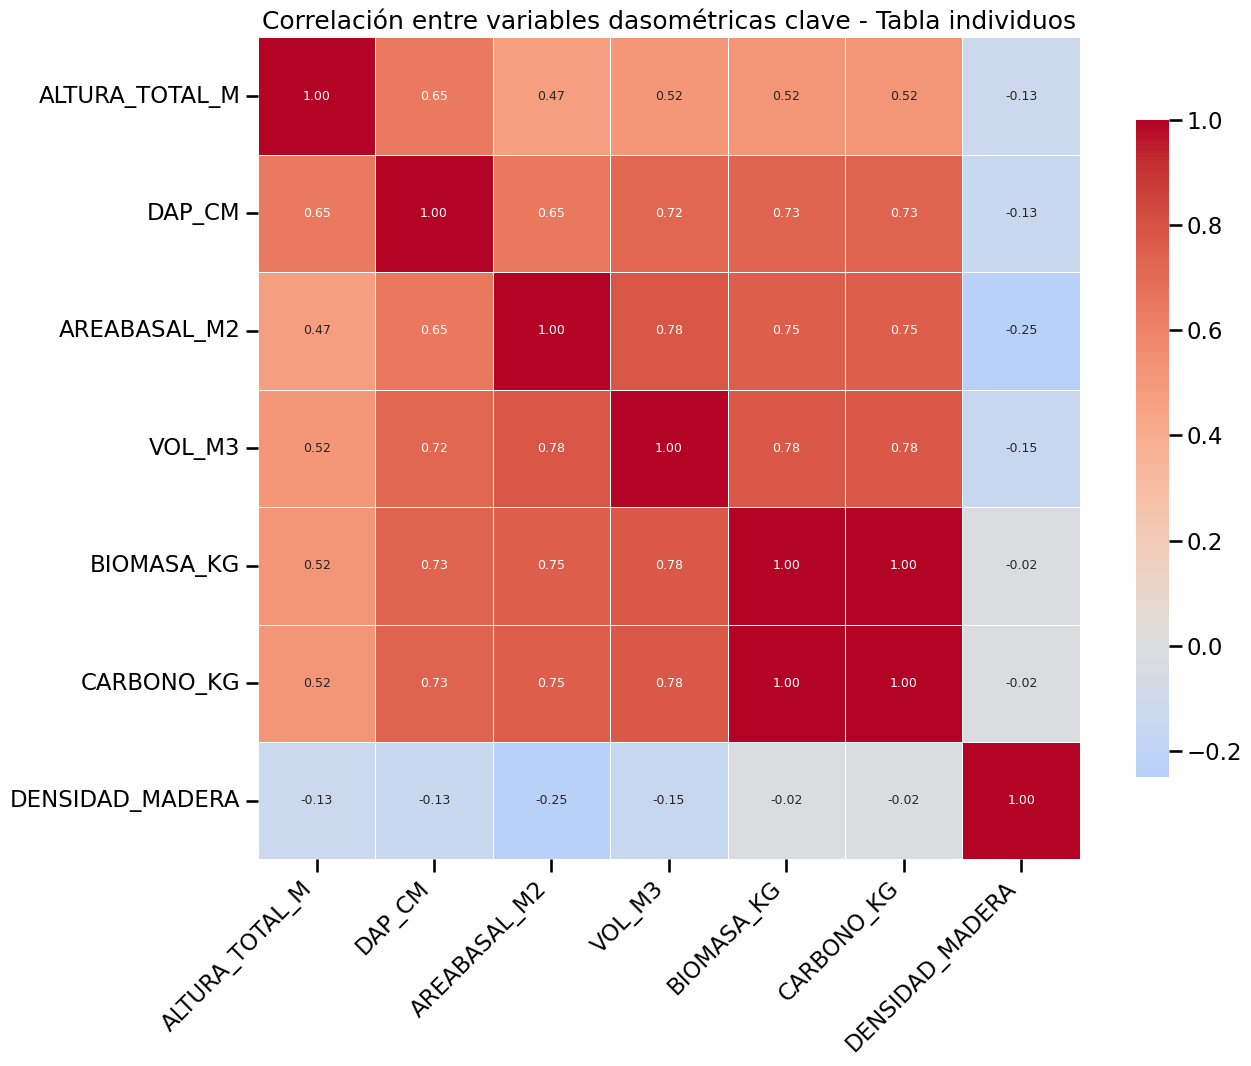

In [147]:
# Correlación entre variables numéricas - Tabla individuos
vars_clave_ind = [
    'ALTURA_TOTAL_M', 'DAP_CM', 'AREABASAL_M2', 'VOL_M3',
    'BIOMASA_KG', 'CARBONO_KG', 'DENSIDAD_MADERA'
]

corr_ind = df_ind[vars_clave_ind].corr()

plt.figure(figsize=(14, 11))
sns.heatmap(corr_ind, cmap='coolwarm', center=0, annot=True, fmt='.2f',   # <-- corr_ind, no corr_um
            annot_kws={'size': 9}, linewidths=0.5, square=True,
            cbar_kws={'shrink': 0.8})
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title('Correlación entre variables dasométricas clave - Tabla individuos')   # <-- título corregido
plt.tight_layout()
plt.show()

A nivel de individuo se repite el mismo patrón, DAP, altura, área basal, volumen, biomasa y carbono correlacionan fuerte entre sí (0.47–0.78), consistente con las relaciones alométricas ya vistas. BIOMASA_KG y CARBONO_KG vuelven a dar 1.00 por ser el carbono una fracción calculada de la biomasa.

DENSIDAD_MADERA es la excepción: correlaciona casi nulo o negativo con el resto, porque es un rasgo propio de cada especie y no depende del tamaño del individuo.

### 1.5. Histogramas y boxplots de todas las variables numéricas


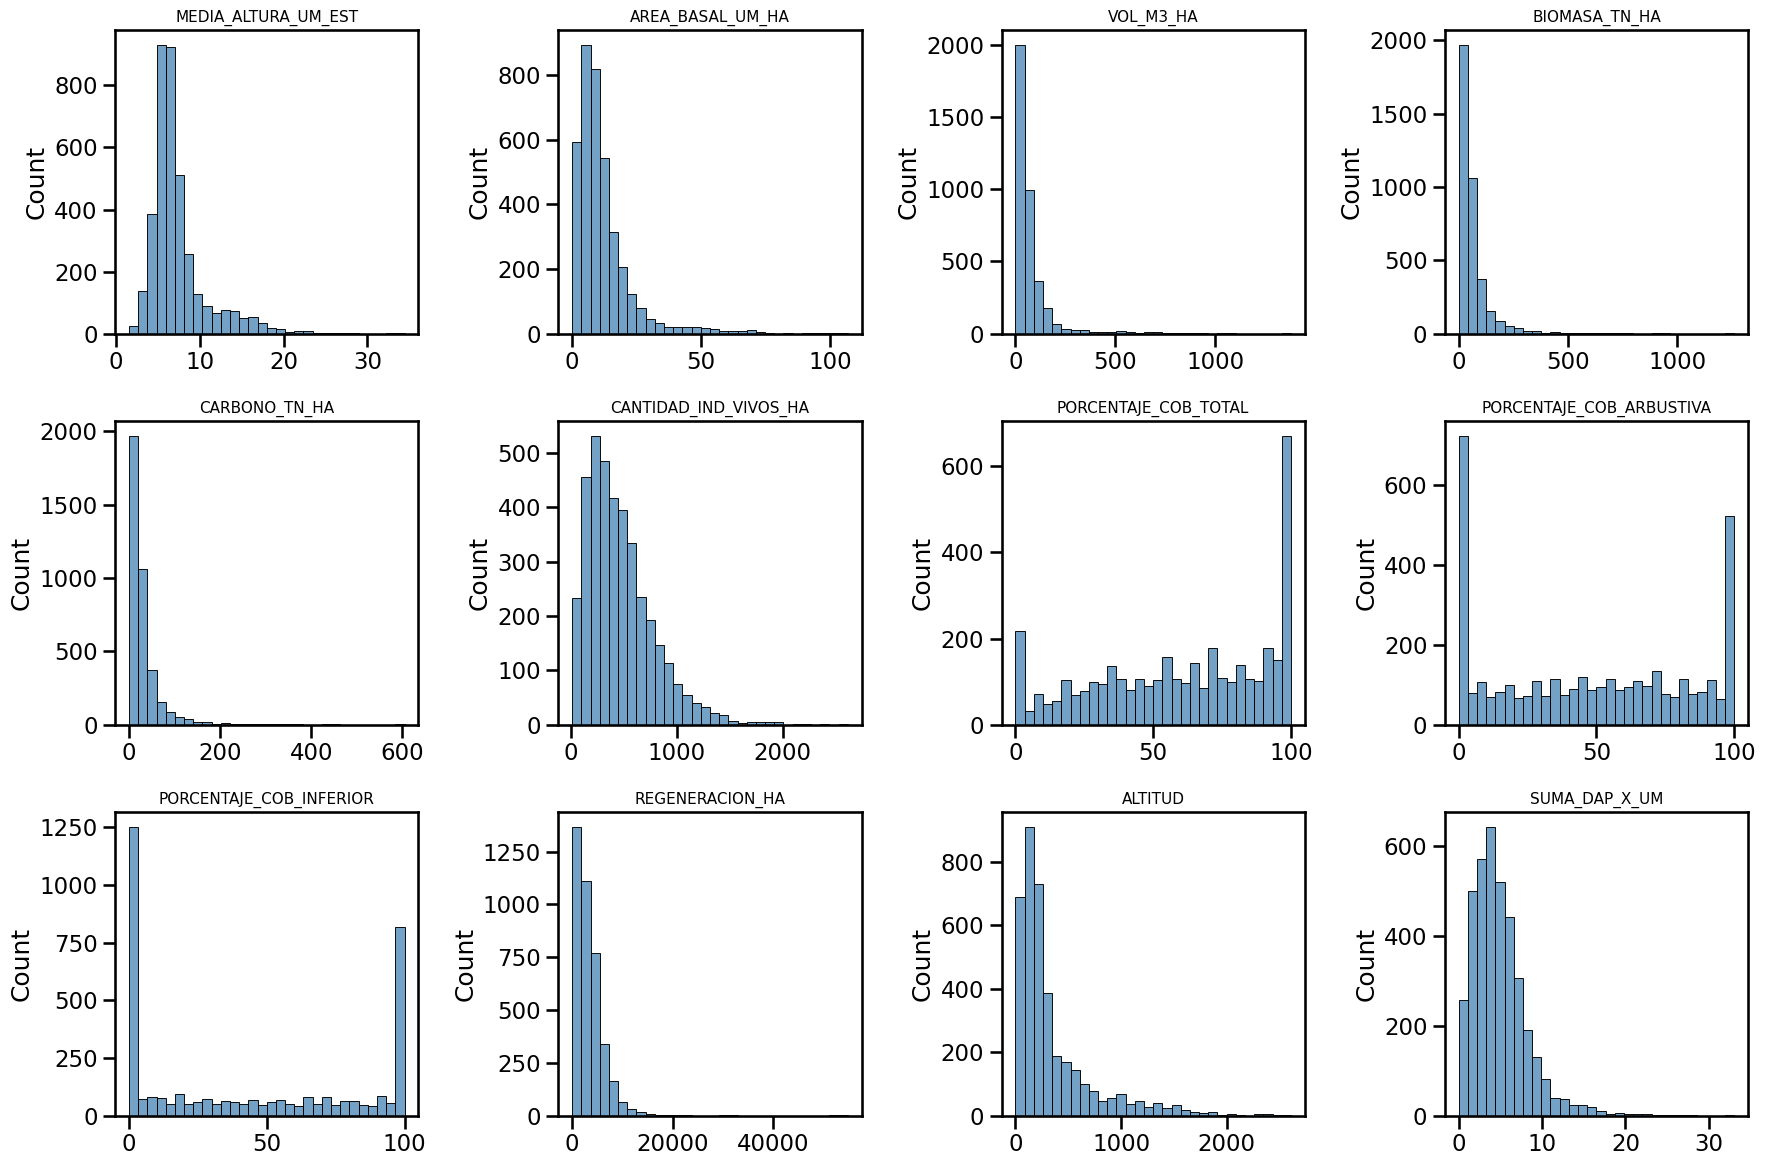

In [148]:
# Histogramas de todas las variables numéricas - Tabla general
vars_hist_um = vars_clave_um  # reutilizamos la misma lista de variables clave

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()
for i, col in enumerate(vars_hist_um):
    sns.histplot(df_um_2022[col].dropna(), bins=30, ax=axes[i], color='steelblue')
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('')
for j in range(i+1, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

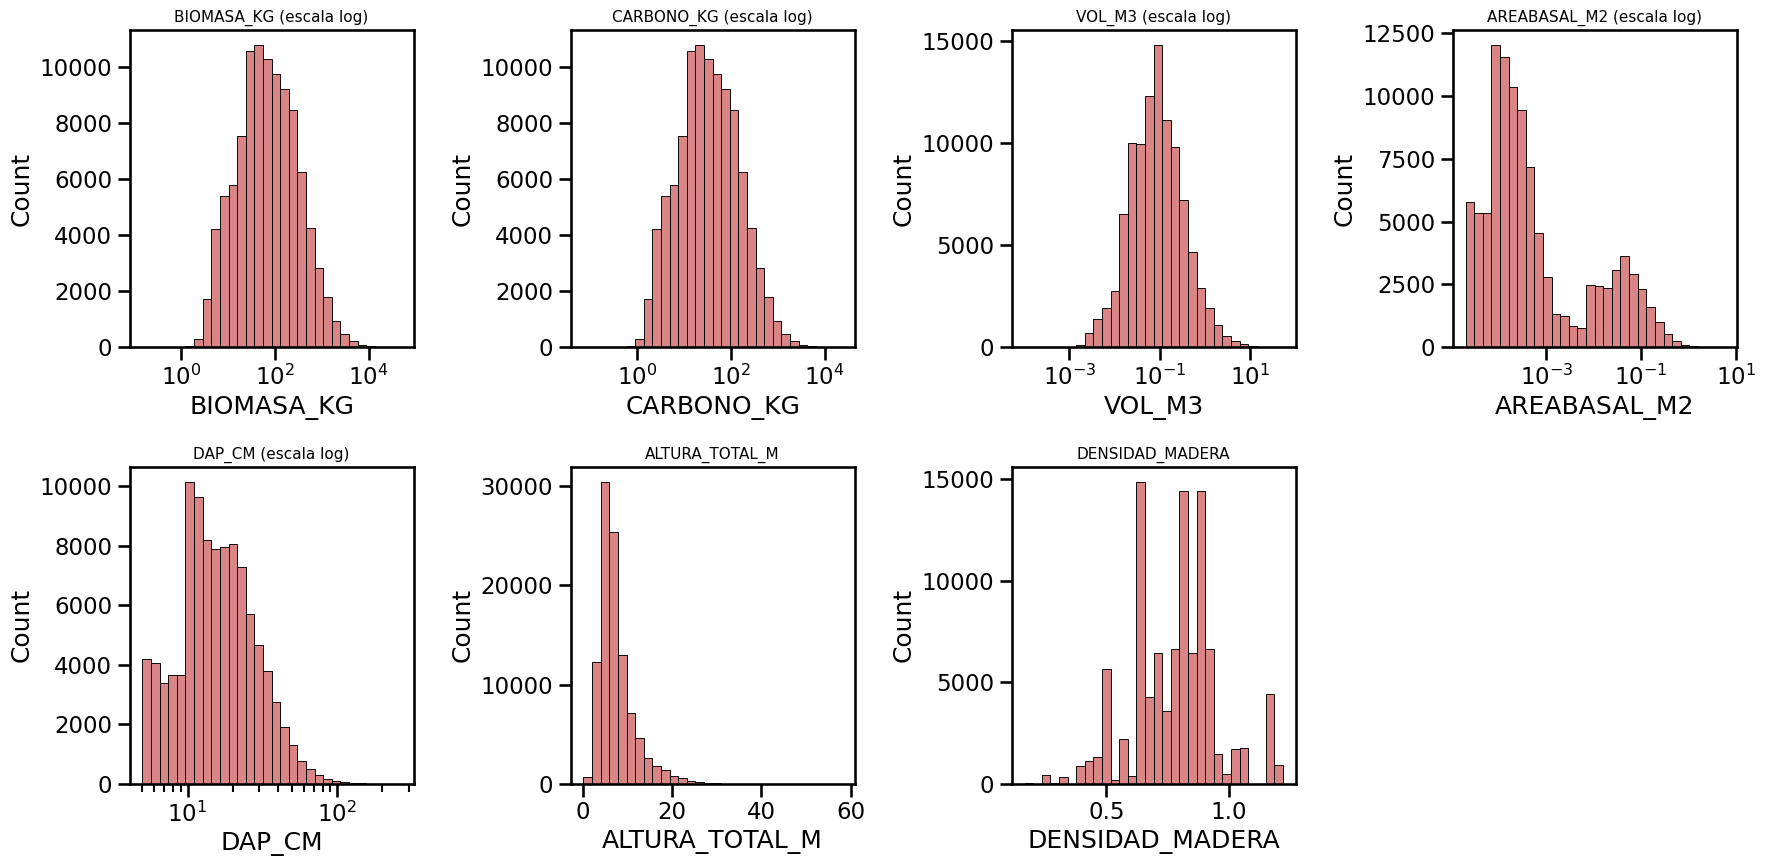

In [149]:
# Histogramas de todas las variables numéricas - Tabla individuos
vars_log_ind = ['BIOMASA_KG', 'CARBONO_KG', 'VOL_M3', 'AREABASAL_M2', 'DAP_CM']
vars_normal_ind = ['ALTURA_TOTAL_M', 'DENSIDAD_MADERA']

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(vars_log_ind):
    data = df_ind[col].dropna()
    data = data[data > 0]  # el log no admite 0/negativos
    sns.histplot(data, bins=30, ax=axes[i], color='indianred', log_scale=True)
    axes[i].set_title(f'{col} (escala log)', fontsize=11)

for j, col in enumerate(vars_normal_ind, start=len(vars_log_ind)):
    sns.histplot(df_ind[col].dropna(), bins=30, ax=axes[j], color='indianred')
    axes[j].set_title(col, fontsize=11)

for k in range(len(vars_log_ind)+len(vars_normal_ind), len(axes)):
    axes[k].axis('off')

plt.tight_layout()
plt.show()

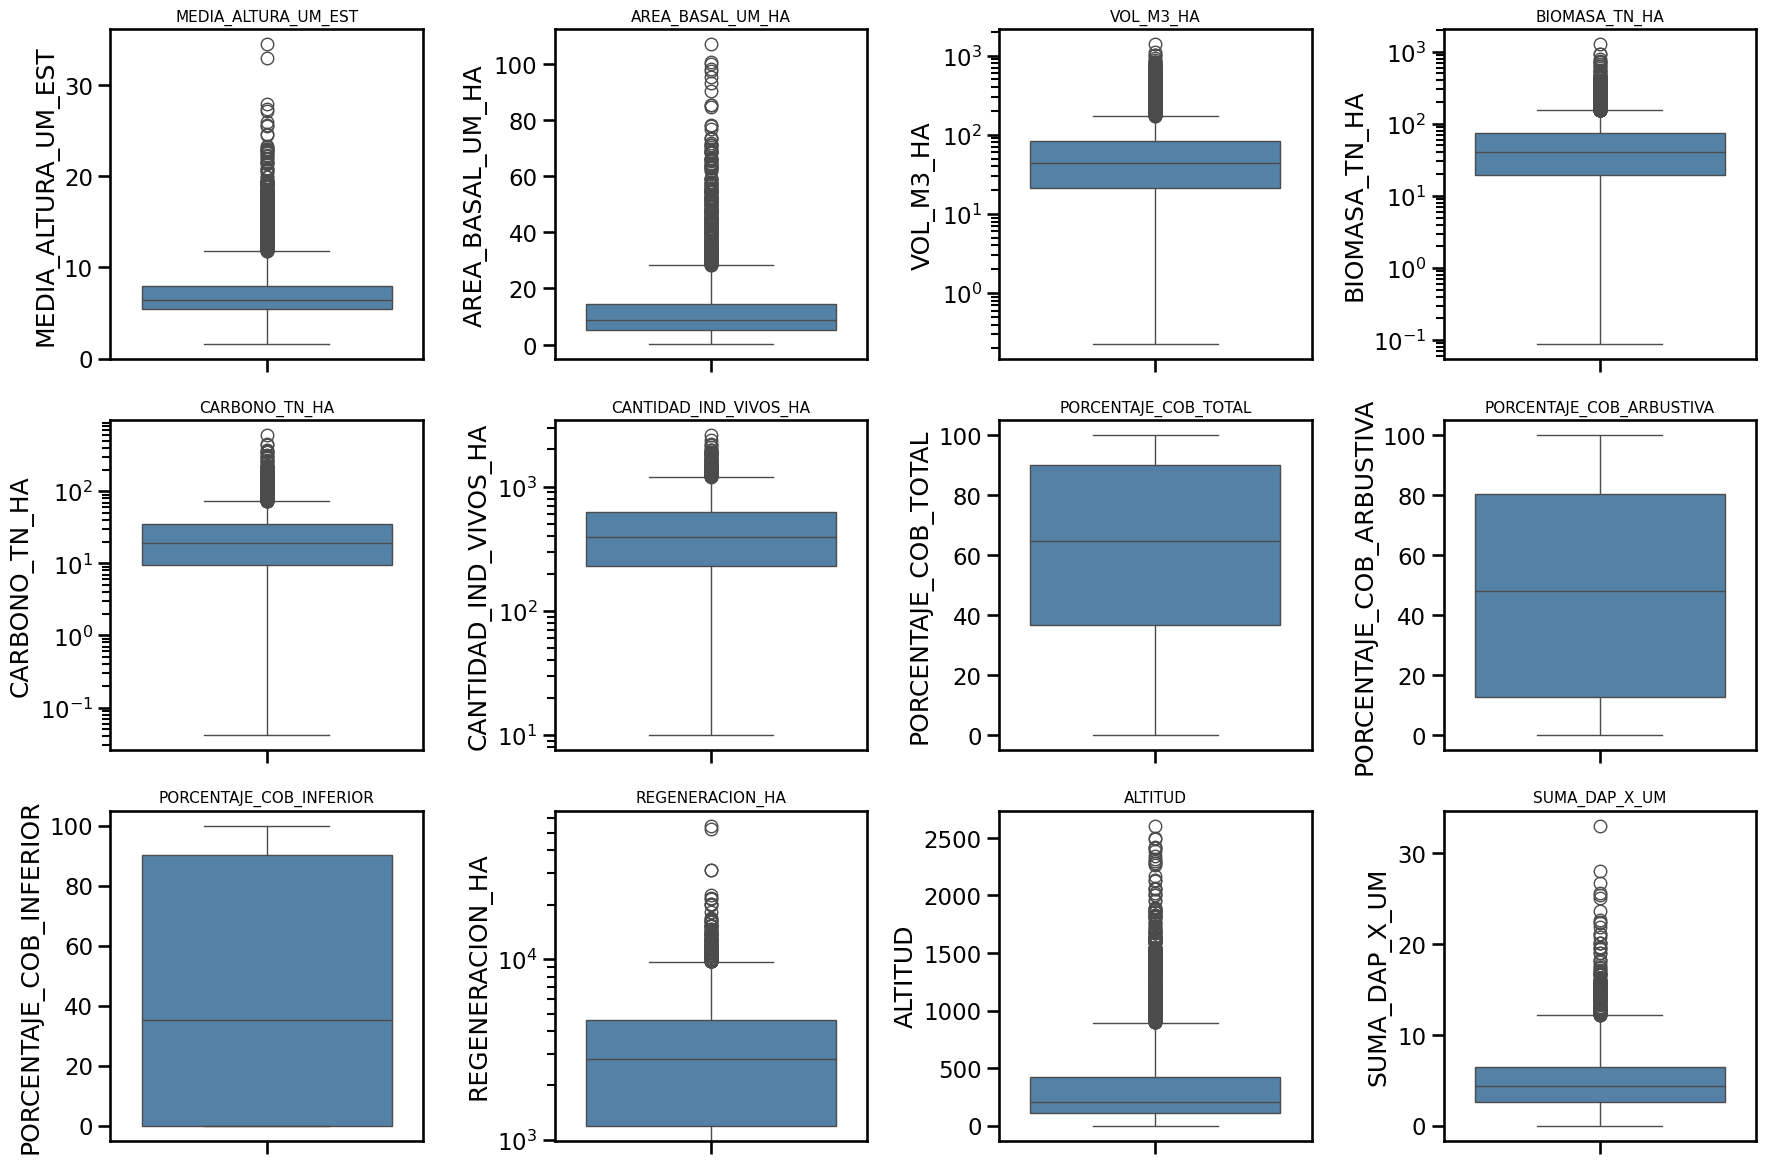

In [150]:
# Boxplots de todas las variables numéricas - Tabla general
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

vars_log_um = ['VOL_M3_HA', 'BIOMASA_TN_HA', 'CARBONO_TN_HA', 'CANTIDAD_IND_VIVOS_HA', 'REGENERACION_HA']

for i, col in enumerate(vars_clave_um):
    sns.boxplot(y=df_um_2022[col], ax=axes[i], color='steelblue')
    axes[i].set_title(col, fontsize=11)
    if col in vars_log_um:
        axes[i].set_yscale('log')
for j in range(i+1, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

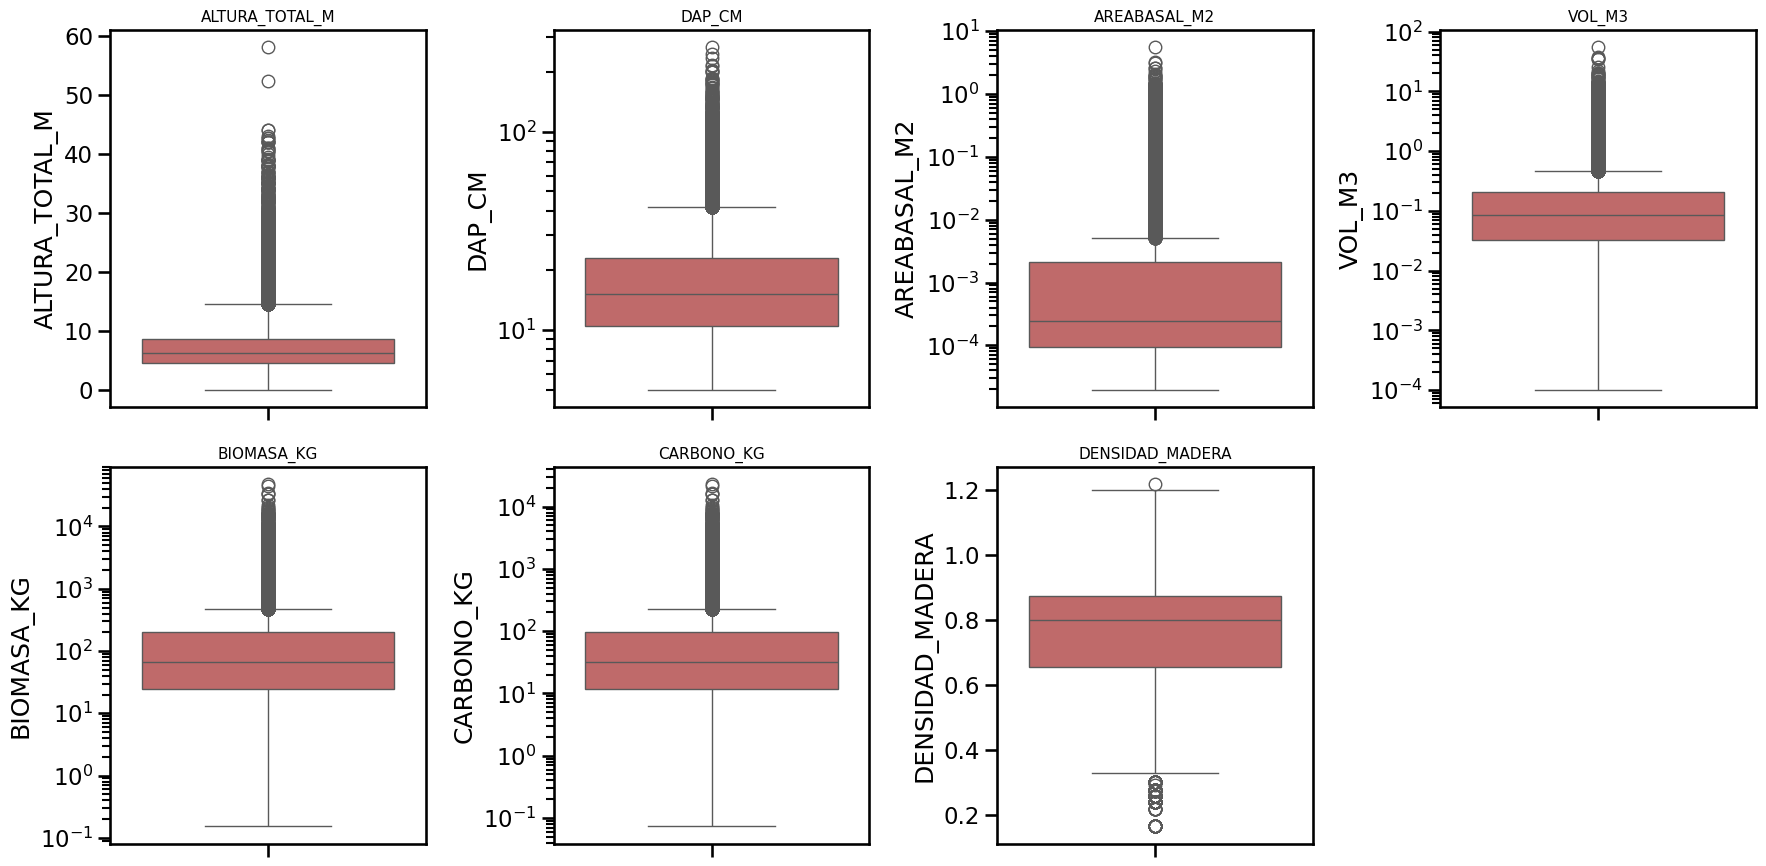

In [151]:
# Boxplots de todas las variables numéricas - Tabla individuos
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

vars_box_ind = vars_clave_ind
vars_log_ind_box = ['BIOMASA_KG', 'CARBONO_KG', 'VOL_M3', 'AREABASAL_M2', 'DAP_CM']

for i, col in enumerate(vars_box_ind):
    data = df_ind[col].copy()
    if col in vars_log_ind_box:
        data = data[data > 0]
    sns.boxplot(y=data, ax=axes[i], color='indianred')
    axes[i].set_title(col, fontsize=11)
    if col in vars_log_ind_box:
        axes[i].set_yscale('log')
for j in range(i+1, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

In [152]:
# Detección de outliers (IQR) en variables dasométricas  - Tabla general
def resumen_outliers_iqr(df, columnas):
    filas = []
    for col in columnas:
        q1, q3 = df[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        lim_inf, lim_sup = q1 - 1.5*iqr, q3 + 1.5*iqr
        n_outliers = ((df[col] < lim_inf) | (df[col] > lim_sup)).sum()
        filas.append({'variable': col, 'n_outliers': n_outliers,
                       'pct_outliers': round(n_outliers/df[col].notnull().sum()*100, 2),
                       'lim_inf': round(lim_inf, 2), 'lim_sup': round(lim_sup, 2)})
    return pd.DataFrame(filas).sort_values('pct_outliers', ascending=False)

print("Outliers - Tabla general (UM):")
display(resumen_outliers_iqr(df_um_2022, vars_clave_um))

Outliers - Tabla general (UM):


,variable,n_outliers,pct_outliers,lim_inf,lim_sup
0,MEDIA_ALTURA_UM_EST,401,10.51,1.52,11.82
10,ALTITUD,388,10.09,-357.88,895.12
4,CARBONO_TN_HA,299,7.84,-29.37,74.23
3,BIOMASA_TN_HA,299,7.84,-61.18,154.64
2,VOL_M3_HA,281,7.40,-70.28,174.27
1,AREA_BASAL_UM_HA,245,6.42,-8.82,28.35
11,SUMA_DAP_X_UM,137,3.59,-3.17,12.16
5,CANTIDAD_IND_VIVOS_HA,110,2.88,-359.85,1209.35
9,REGENERACION_HA,104,2.67,-3900.00,9700.00
6,PORCENTAJE_COB_TOTAL,0,0.00,-43.66,170.42


In [153]:
# Detección de outliers (IQR) en variables dasométricas  - Tabla individuos
print("Outliers - Tabla individuos:")
display(resumen_outliers_iqr(df_ind, vars_clave_ind))

Outliers - Tabla individuos:


,variable,n_outliers,pct_outliers,lim_inf,lim_sup
2,AREABASAL_M2,23220,22.94,-0.00,0.01
3,VOL_M3,10598,10.57,-0.23,0.47
4,BIOMASA_KG,10691,10.56,-239.76,464.76
5,CARBONO_KG,10691,10.56,-115.09,223.09
0,ALTURA_TOTAL_M,6302,6.23,-1.30,14.70
1,DAP_CM,5124,5.06,-8.25,41.75
6,DENSIDAD_MADERA,517,0.51,0.33,1.21


**Interpretación de outliers (IQR):**

En la tabla general, los mayores % se dan en MEDIA_ALTURA_UM_EST y ALTITUD, en las variables estructurales BIOMASA_TN_HA, CARBONO_TN_HA, VOL_M3_HA y AREA_BASAL_UM_HA, coherente con la distribución sesgada vista en los histogramas. El límite inferior de ALTITUD, al ser negativo no es válido, pero identifica que un IQR no es adecuado para variables muy asimétricas. Las variables de cobertura no presentan outliers.

En tabla de inidividuos, los % de outliers aumentan según dependa la variable del tamaño del árbol, porque la mayoría de los inidividuos son juveniles con valores cercanos a cero. VOL_M3, BIOMASA_KG y CARBONO_KG  se mueven juntas por derivarse una de otra. ALTURA_TOTAL_M y DAP_CM tienen menor %. DENSIDAD__MADERA, presenta un % bajo aser un rasgo fijo por especie y no por individuo.

No se eliminan los valores del TP1, ya que reflejan variabilidad biológica real y no errores de carga, en el TP2 se evaluará su tratamiento.

### 1.6. Limpieza y curación de datos


En esta sección se analiza cada grupo de valores faltantes encontrado en la exploración, buscando distinguir entre:
- **Nulos estructurales**: el campo no corresponde para ese caso (ej. no se mide la orientación de una ladera si el terreno es plano).
- **Nulos por cobertura temporal**: la variable se incorporó al protocolo de relevamiento en un año posterior a 2015.
- **Nulos por diseño muestral**: la variable solo se mide en un subconjunto específico de casos (ej. formas de crecimiento particulares).
- **Nulos genuinos**: falta de dato sin justificación clara, candidatos a evaluar imputación o exclusión.

No se aplica una regla general sin antes entender el motivo, porque en varios casos el nulo es información válida y eliminarlo sesgaría el análisis.

In [154]:
# Se cuantifica qué % de los nulos de una variable
def pct_coincidencia(condicion, es_nulo, nombre_cond, nombre_var):
    coincide = (condicion & es_nulo).sum()
    total_nulos = es_nulo.sum()
    total_cond = condicion.sum()
    print(f"{nombre_var} es nulo en {total_nulos} filas.")
    print(f"'{nombre_cond}' se cumple en {total_cond} filas.")
    print(f"Coinciden (nulo Y condición) en {coincide} filas "
          f"-> {coincide/total_nulos*100:.1f}% de los nulos de {nombre_var} "
          f"se explican por '{nombre_cond}'")

In [155]:
# Caso 1 - GANADO_OTRO_TIPO
es_nulo = df_um_2022['GANADO_OTRO_TIPO'].isnull()
condicion = (df_um_2022['GANADO_OTRO'] == 0) | (df_um_2022['GANADO_OTRO'].isnull())
pct_coincidencia(condicion, es_nulo, 'GANADO_OTRO = 0 o NaN', 'GANADO_OTRO_TIPO')

GANADO_OTRO_TIPO es nulo en 3797 filas.
'GANADO_OTRO = 0 o NaN' se cumple en 3797 filas.
Coinciden (nulo Y condición) en 3797 filas -> 100.0% de los nulos de GANADO_OTRO_TIPO se explican por 'GANADO_OTRO = 0 o NaN'


El nulo coincide exactamente con `GANADO_OTRO = 0` o `NaN` (no hay "otro tipo" de ganado presente). Siempre está completo cuando `GANADO_OTRO = 1`.

Nulo estructural, se conserva sin imputar y se interpreta siempre junto a `GANADO_OTRO`.

In [156]:
#Caso 2: GANADO_* y EROSION_*_PRESENCIA
cols_ganado_erosion = ['GANADO_BOVINO','GANADO_OVINO','GANADO_CAPRINO','GANADO_EQUINO',
                        'EROSION_EOLICA_PRESENCIA','EROSION_FISICA_PRESENCIA','EROSION_HIDRICA_PRESENCIA']

nulos_por_anio = df_um_2022.groupby('FECHA_UM_ANIO')[cols_ganado_erosion].apply(lambda s: s.isnull().mean()*100).round(1)
nulos_por_anio

,GANADO_BOVINO,GANADO_OVINO,GANADO_CAPRINO,GANADO_EQUINO,EROSION_EOLICA_PRESENCIA,EROSION_FISICA_PRESENCIA,EROSION_HIDRICA_PRESENCIA
FECHA_UM_ANIO,,,,,,,
2015.0,100.0,100.0,98.2,100.0,100.0,100.0,100.0
2016.0,95.8,97.0,96.4,97.0,97.0,94.6,97.0
2017.0,99.8,99.9,99.9,99.9,99.9,99.9,99.9
2018.0,23.6,29.1,29.2,28.5,29.3,27.8,28.1
2019.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


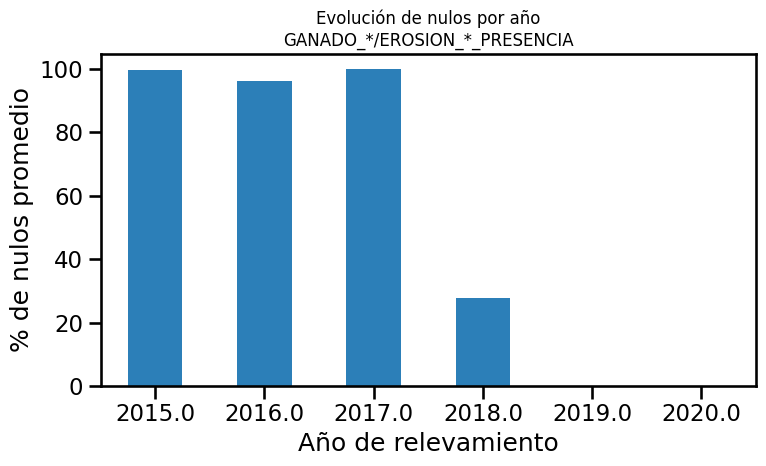

In [157]:
# Visualización de la evolución de nulos por año - Caso 2
fig, ax = plt.subplots(figsize=(8, 5))
nulos_por_anio.mean(axis=1).plot(kind='bar', color='#2c7fb8', ax=ax)
ax.set_ylabel('% de nulos promedio')
ax.set_xlabel('Año de relevamiento')
ax.set_title('Evolución de nulos por año\nGANADO_*/EROSION_*_PRESENCIA', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()

El % de nulos cae de 100% (2015-2017) a 0% (2019-2020). Estas variables se incorporaron al protocolo de relevamiento recién en 2018-2019; en los años anteriores directamente no se relevaban.

Nulo por cobertura temporal, no se debe a un error de carga. Se conserva la columna, pero cualquier análisis que use estas variables debe excluir o tratar aparte las UM relevadas antes de 2018, ya que para esos años el nulo significa "dato no relevado", imputar con 0 sería incorrecto y sesgaría el resultado hacia menos presencia de ganado/erosión de la real.

In [158]:
# Caso 3 - MEDIA_ALT_TOCONES / MEDIA_DAB_TOCONES
es_nulo = df_um_2022['MEDIA_ALT_TOCONES'].isnull()
condicion = df_um_2022['CANTIDAD_TOCONES_X_UM'] == 0
pct_coincidencia(condicion, es_nulo, 'CANTIDAD_TOCONES_X_UM = 0', 'MEDIA_ALT_TOCONES')

MEDIA_ALT_TOCONES es nulo en 2837 filas.
'CANTIDAD_TOCONES_X_UM = 0' se cumple en 2837 filas.
Coinciden (nulo Y condición) en 2837 filas -> 100.0% de los nulos de MEDIA_ALT_TOCONES se explican por 'CANTIDAD_TOCONES_X_UM = 0'


El nulo coincide 100% con `CANTIDAD_TOCONES_X_UM = 0` (no hay tocones en la parcela, por lo tanto no hay altura/diámetro de tocón para promediar).

Nulo estructural. Se conserva sin imputar.

In [159]:
# Caso 4 - EXPOSICIÓN
es_nulo = df_um_2022['EXPOSICION'].isnull()
condicion = df_um_2022['PENDIENTE_CATEGORIA'] == 'sin_pendiente'
pct_coincidencia(condicion, es_nulo, 'PENDIENTE_CATEGORIA = sin_pendiente', 'EXPOSICION')

EXPOSICION es nulo en 3367 filas.
'PENDIENTE_CATEGORIA = sin_pendiente' se cumple en 2870 filas.
Coinciden (nulo Y condición) en 2868 filas -> 85.2% de los nulos de EXPOSICION se explican por 'PENDIENTE_CATEGORIA = sin_pendiente'


El nulo coincide con `PENDIENTE_CATEGORIA = sin_pendiente` en la gran mayoría de los casos (2.868 de 3.367), la orientación de una ladera no aplica en terreno plano.

Nulo estructural. Se conserva sin imputar.

In [160]:
# Caso 5 - CUENCA_FORESTAL
df_um_2022.groupby('REGION_OFC')['CUENCA_FORESTAL'].apply(lambda s: s.isnull().mean()*100).round(1)

,CUENCA_FORESTAL
REGION_OFC,
BAP,93.8
DEL,100.0
ESP,100.0
MON,99.0
PCH,88.6
SMI,71.7
STB,74.5


In [161]:
# Columna auxiliar (complementaria a CUENCA_FORESTAL)
df_um_2022['CUENCA_FORESTAL_CAT'] = df_um_2022['CUENCA_FORESTAL'].fillna('Sin cuenca asignada')

df_um_2022['CUENCA_FORESTAL_CAT'].value_counts()

,count
CUENCA_FORESTAL_CAT,
Sin cuenca asignada,3434
Impenetrable,230
Guadalcazar,67
Caimancito,54
Yaboti,47
Oran,30
Tolhuin,15
Guillermina,14


El % de nulos es alto en todas las regiones (72%-100%), sin patrón temporal ni regional claro. Los valores no nulos corresponden a solo 7 cuencas forestales nombradas (ej. "Impenetrable", "Guadalcázar"), lo que sugiere que la variable identifica UM que caen dentro de un conjunto acotado de cuencas forestales prioritarias, no una clasificación universal.

Nulo estructural ("la UM no pertenece a ninguna cuenca forestal prioritaria definida"). Se conserva la columna. Para visualizaciones se modifica el NaN como categoría explícita `"Sin cuenca asignada" para que no se confunda con dato faltante.

In [162]:
# Caso 6: Ley_N2_06
nulos_ley = df_um_2022.groupby('FECHA_UM_ANIO')['Ley_N2_06'].apply(lambda s: s.isnull().mean()*100).round(1)
nulos_ley

,Ley_N2_06
FECHA_UM_ANIO,
2015.0,100.0
2016.0,100.0
2017.0,99.9
2018.0,72.6
2019.0,60.2
2020.0,49.4


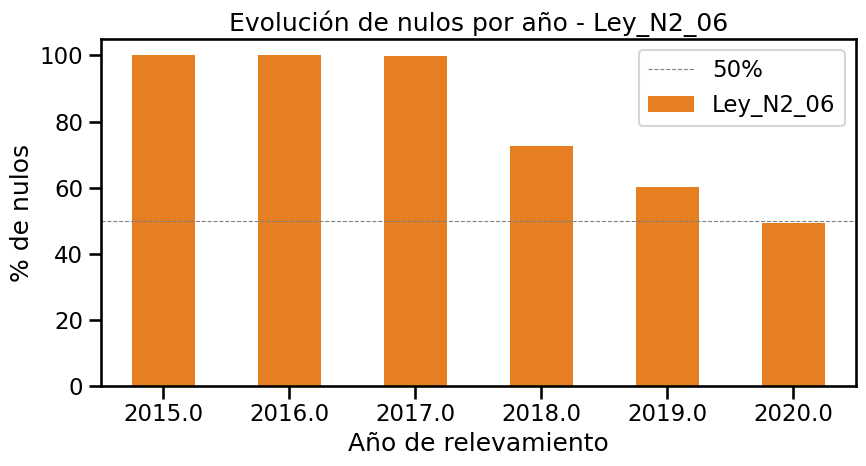

In [163]:
# Visualización de la evolución de nulos por año - Caso 6
plt.figure(figsize=(9, 5))
nulos_ley.plot(kind='bar', color='#e67e22')
plt.ylabel('% de nulos')
plt.xlabel('Año de relevamiento')
plt.title('Evolución de nulos por año - Ley_N2_06')
plt.axhline(50, color='gray', linestyle='--', linewidth=0.8, label='50%')
plt.legend()
plt.xticks(rotation=0)
plt.tight_layout()

Los nulos bajan de 100% (2015-2017) a 49% (2020), es una variable de clasificación de vegetación (ej. "Bosque de algarrobos", "Selva montana") que se fue incorporando progresivamente, pero nunca llegó a cobertura completa.

Se observa que queda con 50% nulos incluso en el mejor año. Se conserva la columna para análisis exploratorios puntuales, pero no se usará como variable de agrupamiento o filtro principal por su baja cobertura.

In [164]:
# Caso 7: variables de copa/DAB en individuos
mask_copa = df_ind['DIAMETRO_COPA_1'].notnull()
print("Individuos con DIAMETRO_COPA_1 medido:", mask_copa.sum(), "de", len(df_ind))
print("UM distintas involucradas:", df_ind.loc[mask_copa, 'UM_ID_UM'].nunique(), "de", df_ind['UM_ID_UM'].nunique())
print()
print("DAP_CM en esos individuos (con copa medida):")
print(df_ind.loc[mask_copa, 'DAP_CM'].describe())

Individuos con DIAMETRO_COPA_1 medido: 981 de 101229
UM distintas involucradas: 92 de 3815

DAP_CM en esos individuos (con copa medida):
count    981.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: DAP_CM, dtype: float64


Solo 981 individuos (0.97%) tienen estas variables medidas, concentrados en apenas 92 de las 3.815 UM. En todos esos casos `DAP_CM = 0,`es decir son individuos de forma arbustiva sin fuste único medible, para los que se registró diámetro de copa en lugar de diámetro de tronco.

Es una medición alternativa para una forma de crecimiento distinta (arbustiva vs. arbórea). Se conserva la columna.

Para análisis de estructura arbórea (DAP, altura, biomasa por diámetro) se tratará estos 981 casos en un análisis aparte, ya que mezclar DAP=0 con el resto sesgaría cualquier estadística de diámetro.

In [165]:
# Caso 8: nulos residuales de bajo impacto
print("VOL_M3 nulo — ¿se relaciona con algún patrón?")
print(df_ind[df_ind['VOL_M3'].isnull()][['ESTADO_INDIV','DAP_CM','ALTURA_TOTAL_M']].describe(include='all'))

VOL_M3 nulo — ¿se relaciona con algún patrón?
       ESTADO_INDIV      DAP_CM  ALTURA_TOTAL_M
count           987  987.000000      987.000000
unique            4         NaN             NaN
top               2         NaN             NaN
freq            444         NaN             NaN
mean            NaN    0.112570        2.419453
std             NaN    1.626175        0.895326
min             NaN    0.000000        0.400000
25%             NaN    0.000000        1.800000
50%             NaN    0.000000        2.300000
75%             NaN    0.000000        2.900000
max             NaN   36.000000        9.100000


Son nulos residuales de baja magnitud (inferior a 1%), sin patrón sistemático evidente ligado a una variable de diseño.

Por su bajo volumen y sin evidencia de sesgo, se dejan como `NaN` sin imputar (no afectan significativamente ningún agregado) en lugar de inventar un valor. Se excluyen en cualquier cálculo que use `.dropna()` o funciones de agregación de pandas, que ya ignoran `NaN` por defecto.

In [166]:
# Caso 9: MEDIA_ALTURA_UM_EST y otras variables agregadas nulas
um_sin_individuos = set(df_um_2022['UM_ID_UM']) - set(df_ind['UM_ID_UM'])
print("UM sin individuos:", len(um_sin_individuos))
print(df_um_2022[df_um_2022['UM_ID_UM'].isin(um_sin_individuos)]['PRESENTA_IND_INVENTARIABLE'].value_counts())

# ¿Estas 76 UM explican los nulos vistos en 1.2 para las variables agregadas?
subset = df_um_2022[df_um_2022['UM_ID_UM'].isin(um_sin_individuos)]
print()
for col in ['BIOMASA_TN_HA', 'CARBONO_TN_HA', 'MEDIA_ALTURA_UM_EST', 'VOL_M3_HA']:
    total_nulos = df_um_2022[col].isnull().sum()
    en_subset = subset[col].isnull().sum()
    print(f"{col}: {en_subset}/{total_nulos} de los nulos totales "
          f"corresponden a UM sin individuos ({en_subset/total_nulos*100:.1f}%)")

UM sin individuos: 76
PRESENTA_IND_INVENTARIABLE
NO    76
Name: count, dtype: int64

BIOMASA_TN_HA: 76/76 de los nulos totales corresponden a UM sin individuos (100.0%)
CARBONO_TN_HA: 76/76 de los nulos totales corresponden a UM sin individuos (100.0%)
MEDIA_ALTURA_UM_EST: 76/76 de los nulos totales corresponden a UM sin individuos (100.0%)
VOL_M3_HA: 76/96 de los nulos totales corresponden a UM sin individuos (79.2%)


La columna `PRESENTA_IND_INVENTARIABLE` representa en la tabla general bosque relevado sin individuos inventariables.

El cruce confirma que estas 76 UM explican el 100% de los nulos de `BIOMASA_TN_HA`, `CARBONO_TN_HA` y `MEDIA_ALTURA_UM_EST` vistos en la exploración de la sección 1.2, y el 79.2% de los de `VOL_M3_HA` (el 20.8% restante queda como nulo residual, similar al Caso 8).

Como es un dato real y válido, se conservan estas 76 UM en la tabla general, pero se excluyen de cualquier análisis a nivel de individuo o de estructura arbórea, donde no aportan información.

### Resumen de la limpieza aplicada

| Variable(s) | % nulos | Causa | Decisión |
|---|---|---|---|
| GANADO_OTRO_TIPO | 97.6% | No aplica (no hay "otro" ganado) | Conservar sin imputar |
| GANADO_* / EROSION_*_PRESENCIA | 35-36% | No relevado antes de 2018 | Conservar; excluir <2018 en análisis de ganado/erosión |
| MEDIA_ALT/DAB_TOCONES | 72.9% | No aplica (sin tocones) | Conservar sin imputar |
| EXPOSICION | 86.5% | No aplica (terreno plano) | Conservar sin imputar |
| CUENCA_FORESTAL | 88.3% | No pertenece a cuenca prioritaria | Conservar; recodificar a categoría explícita |
| Ley_N2_06 | 73-77% | Cobertura incompleta, incluso reciente | Conservar; no usar como variable principal |
| DIAMETRO_COPA_1/2, DAB_CM, etc. (individuos) | 98-99% | Medición alternativa para forma arbustiva | Conservar; excluir de análisis de estructura arbórea |
| VOL_M3/VOL_M3_HA, ALTURA_TOTAL_M (individuos) | <1% | Sin patrón claro, bajo volumen | Dejar como NaN, no imputar |
| Duplicados UM_ID_UM+NO_INDIV (falso positivo) | — | Clave mal definida (falta PARCELA_CONCENTRICA) | Corregido en el código, no se elimina ninguna fila |
| 76 UM sin individuos / variables agregadas nulas | — | Parcelas sin individuos inventariables (confirmado por `PRESENTA_IND_INVENTARIABLE`) | Conservar en tabla general, excluir de análisis a nivel individuo |

No se eliminó ninguna fila ni columna del dataset. Todos los nulos detectados tienen una explicación estructural, temporal o de diseño muestral documentada, y se resuelven mediante reglas de uso condicional (qué variable usar en qué contexto) en lugar de imputación o eliminación, para no introducir sesgos ni perder información real del relevamiento.

### 1.7. Combinación de tablas

Antes de profundizar en análisis que requieren cruzar información de individuo y de parcela (especie + región, especie + biomasa de la UM, etc.), unimos ambas tablas por `UM_ID_UM`. Aprovechamos para hacer un chequeo de consistencia,  recalcular desde `df_ind` algunos agregados que ya existen en `df_um_2022`, y comparar.

In [167]:
# Agregados recalculados desde la tabla de individuos, a nivel de UM
agg_ind = df_ind.groupby('UM_ID_UM').agg(
    n_individuos_calc=('NO_INDIV', 'count'),
    altura_media_calc=('ALTURA_TOTAL_EST', 'mean'),
    biomasa_kg_total=('BIOMASA_KG', 'sum'),
    n_especies=('ESPECIE_CORREGIDA', 'nunique'),
).reset_index()

# Comparación contra el valor ya calculado en la tabla general
comparacion = df_um_2022[['UM_ID_UM', 'CANTIDAD_IND_VIVOS_UM']].merge(agg_ind, on='UM_ID_UM', how='left')
comparacion['diferencia'] = comparacion['CANTIDAD_IND_VIVOS_UM'] - comparacion['n_individuos_calc']

print("Diferencia media (tabla general - recalculado):", comparacion['diferencia'].mean().round(3))
print("UM con diferencia distinta de 0:", (comparacion['diferencia'].abs() > 0).sum(), "de", len(comparacion))
comparacion['diferencia'].describe()

Diferencia media (tabla general - recalculado): -0.104
UM con diferencia distinta de 0: 326 de 3891


,diferencia
count,3815.000000
mean,-0.104063
std,0.413361
min,-7.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,2.000000


**Chequeo de consistencia:** al recalcular la cantidad de individuos por UM desde `df_ind` y compararla con `CANTIDAD_IND_VIVOS_UM` de la tabla general, el 91.6% de las UM (3.565 de 3.891) coincide exactamente, y la diferencia promedio es de apenas -0.1 individuos. Los casos con diferencia (326 UM) probablemente respondan a criterios de reclasificación de estado del individuo (vivo/muerto/en pie/caído) entre el momento de carga de la tabla de individuos y el cálculo de los agregados de la tabla general. **No es una inconsistencia grave**: valida que ambas tablas describen la misma realidad de campo y que el cruce por `UM_ID_UM` es confiable para el resto del análisis.

In [168]:
# Dataset combinado: cada individuo con el contexto de su parcela
cols_um_contexto = ['UM_ID_UM', 'REGION_OFC', 'SUBREG', 'PROVINCIA', 'ALTITUD',
                     'PENDIENTE_CATEGORIA', 'AREA_BASAL_UM_HA', 'VOL_M3_HA',
                     'BIOMASA_TN_HA', 'CARBONO_TN_HA']

df_individuos_um = df_ind.merge(df_um_2022[cols_um_contexto], on='UM_ID_UM', how='left', suffixes=('', '_UM'))
print("Dataset combinado (individuos + contexto de parcela):", df_individuos_um.shape)
df_individuos_um.head()

Dataset combinado (individuos + contexto de parcela): (101229, 40)


,UM_ID_UM,NO_INDIV,PARCELA_CONCENTRICA,ESPECIE_CORREGIDA,REGION_OFC,SUBREG,ESTADO_INDIV,ALTURA_TOTAL_M,PROVINCIA,COORDENADAS_GPS_LATITUDE2,COORDENADAS_GPS_LONGITUDE2,DAP_FINAL_M,ALTURA_TOTAL_EST,VOL_M3,VOL_M3_HA,DAP_CM,AREABASAL_CM2,AREABASAL_M2,DENSIDAD_MADERA,BIOMASA_KG,CARBONO_KG,CLASE_DIAM,BIOMASA_TN_HA,CARBONO_TN_HA,MEDIA_DIAM_COPA,DAB_FINAL_M,DIAMETRO_COPA_1,DIAMETRO_COPA_2,DAB_CM,Ley_N1_06,Ley_N2_06,REGION_OFC_UM,SUBREG_UM,PROVINCIA_UM,ALTITUD,PENDIENTE_CATEGORIA,AREA_BASAL_UM_HA,VOL_M3_HA_UM,BIOMASA_TN_HA_UM,CARBONO_TN_HA_UM
0,6074195,1,A,Prosopis alpataco,MON,Monte,2,4.2,6,-39.366333,-63.273639,0.118381,4.2,0.027448,0.274485,11.838074,110.065699,0.011007,0.792,27.071153,12.994154,[10-20),0.270712,0.129942,0.0,0.0,NaN,NaN,NaN,OTF,Bosque mixto,MON,Monte,6.0,41.0,sin_pendiente,1.560872,1.728589,2.941308,1.411828
1,6074195,3,A,UNLISTED,MON,Monte,3,4.8,6,-39.366333,-63.273639,0.101607,4.8,0.014682,0.146822,10.160709,81.084506,0.008108,0.715,20.712136,9.941825,[10-20),0.207121,0.099418,0.0,0.0,NaN,NaN,NaN,OTF,Bosque mixto,MON,Monte,6.0,41.0,sin_pendiente,1.560872,1.728589,2.941308,1.411828
2,6074195,8,A,UNLISTED,MON,Monte,4,4.4,6,-39.366333,-63.273639,0.082219,4.4,0.012296,0.122964,8.221922,53.092916,0.005309,0.715,12.585068,6.040833,[5-10),0.125851,0.060408,0.0,0.0,NaN,NaN,NaN,OTF,Bosque mixto,MON,Monte,6.0,41.0,sin_pendiente,1.560872,1.728589,2.941308,1.411828
3,6074195,9,A,UNLISTED,MON,Monte,2,3.5,6,-39.366333,-63.273639,0.077987,3.5,0.011824,0.118236,7.798718,47.767916,0.004777,0.715,9.079407,4.358115,[5-10),0.090794,0.043581,0.0,0.0,NaN,NaN,NaN,OTF,Bosque mixto,MON,Monte,6.0,41.0,sin_pendiente,1.560872,1.728589,2.941308,1.411828
4,6074195,25,A,UNLISTED,MON,Monte,3,3.7,6,-39.366333,-63.273639,0.121655,3.7,0.017004,0.170042,12.165525,116.238928,0.011624,0.715,22.832742,10.959716,[10-20),0.228327,0.109597,0.0,0.0,NaN,NaN,NaN,OTF,Bosque mixto,MON,Monte,6.0,41.0,sin_pendiente,1.560872,1.728589,2.941308,1.411828


Se genera `df_individuos_um`: cada fila sigue siendo un individuo, pero ahora incluye el contexto de su parcela (región, altitud, biomasa/carbono por hectárea de la UM, etc.). Esta tabla es la base para los análisis de especie y región que siguen.

### 1.8. Visualización espacial

Al explorar las coordenadas de la tabla general (`LATITUD_INSTALACION`, `LONGITUD_INSTALACION`, `LATITUD_GRILLA`, `LONGITUD_GRILLA`) se detectó que están en valores del orden de miles de millones, no grados decimales. Es un problema de esas columnas puntuales en `df_um_2022`, ya identificado antes al comparar 2021 vs 2022 (eran de las variables con más diferencias entre versiones).

En cambio, las coordenadas de `df_ind` (`COORDENADAS_GPS_LATITUDE2/LONGITUDE2`) sí están en un rango válido para Argentina (lat -22 a -55, lon -53 a -73). Por eso, para ubicar espacialmente cada UM, promediamos las coordenadas de sus individuos.

In [169]:
# Coordenadas de UM a partir del promedio de coordenadas de sus individuos
coords_um = df_ind.groupby('UM_ID_UM')[['COORDENADAS_GPS_LATITUDE2', 'COORDENADAS_GPS_LONGITUDE2']].mean().reset_index()
coords_um.columns = ['UM_ID_UM', 'LAT_UM', 'LON_UM']

df_um_geo = df_um_2022.merge(coords_um, on='UM_ID_UM', how='inner')
print("UM con coordenadas válidas:", df_um_geo.shape[0], "de", df_um_2022.shape[0])

UM con coordenadas válidas: 3815 de 3891


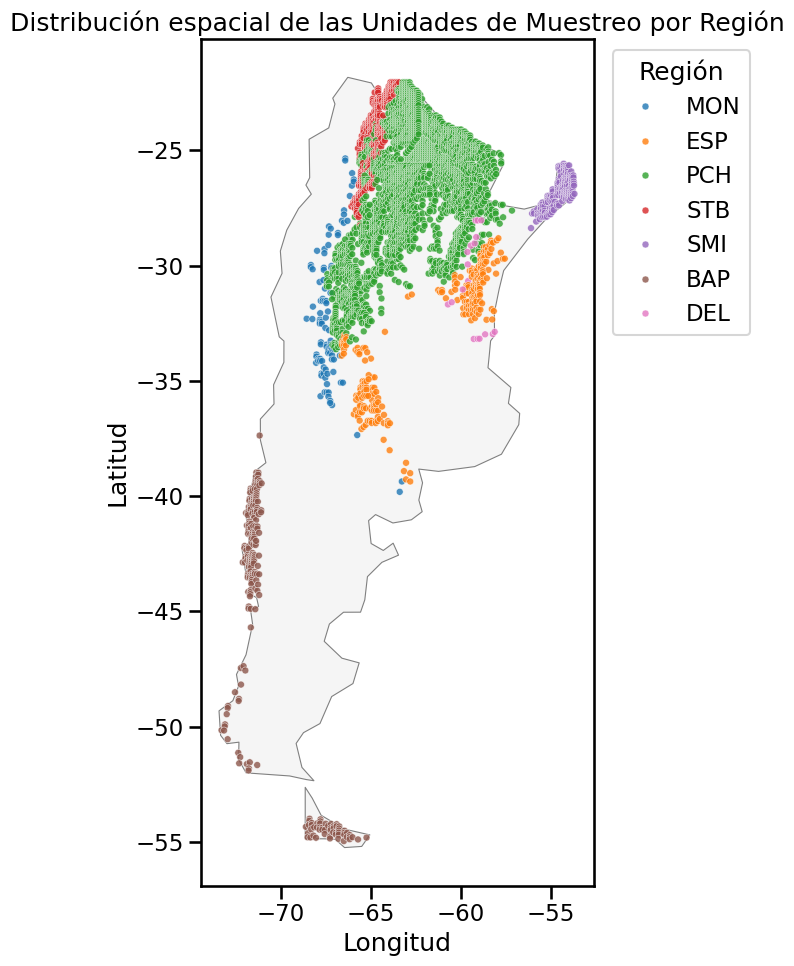

In [170]:
# Mapa de dispersión de las UM, coloreado por región

url_argentina = "https://raw.githubusercontent.com/johan/world.geo.json/master/countries/ARG.geo.json"
urllib.request.urlretrieve(url_argentina, "argentina.geojson")
argentina = gpd.read_file("argentina.geojson")   # <-- línea agregada

fig, ax = plt.subplots(figsize=(9, 10))

argentina.plot(ax=ax, color='whitesmoke', edgecolor='gray', linewidth=0.8, zorder=1)

sns.scatterplot(data=df_um_geo, x='LON_UM', y='LAT_UM', hue='REGION_OFC',
                 palette='tab10', s=25, alpha=0.8, ax=ax, zorder=2)

ax.set_title('Distribución espacial de las Unidades de Muestreo por Región')
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
ax.legend(title='Región', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

El mapa de UM coloreado por región muestra la geografía real de los principales macizos argentinos: el Parque Chaqueño **(PCH, verde)** concentra la mayor densidad de puntos y ocupa el centro-norte del país, coherente con ser la región con más superficie de bosque nativo remanente.

El Bosque Andino Patagónico **(BAP, marrón)** se despliega en una franja angosta a lo largo de la cordillera, desde Neuquén hasta Tierra del Fuego.

Selva Misionera **(SMI, violeta)** aparece como compacto y aislado en el extremo noreste, es la región de menor superficie entre las relevadas.

Espinal **(ESP, naranja)** y Delta e Islas del Paraná **(DEL, rosa)** se ubican como zonas de transición entre el Parque Chaqueño y la región pampeana/litoral.

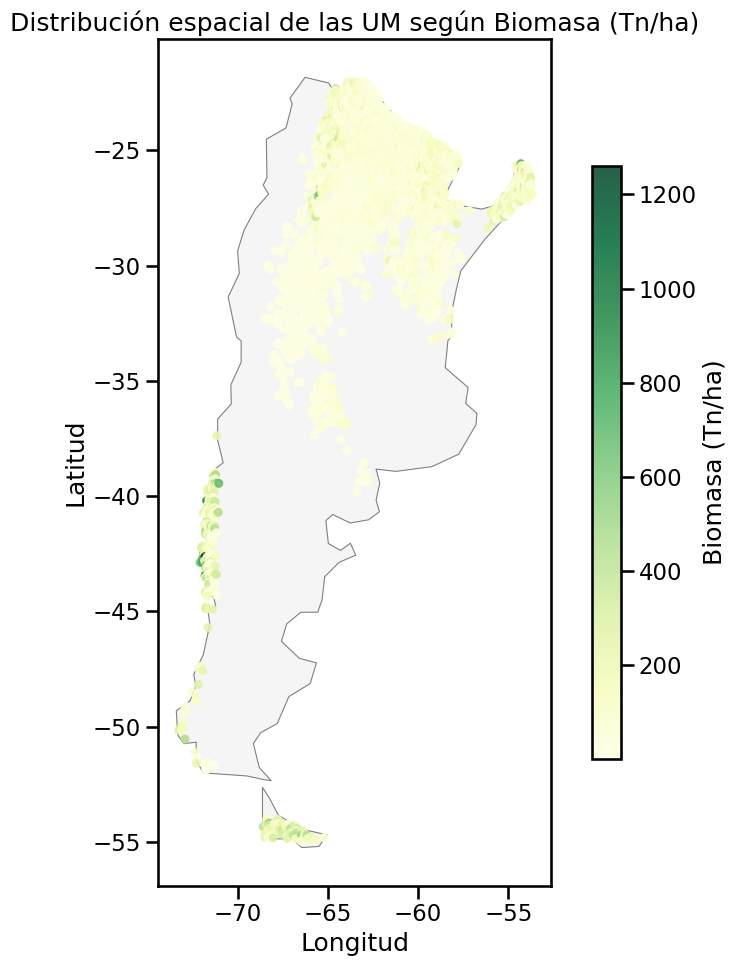

In [171]:
# Mapa de dispersión coloreado por biomasa (intensidad continua)
fig, ax = plt.subplots(figsize=(9, 10))

argentina.plot(ax=ax, color='whitesmoke', edgecolor='gray', linewidth=0.8, zorder=1)

sc = ax.scatter(df_um_geo['LON_UM'], df_um_geo['LAT_UM'], c=df_um_geo['BIOMASA_TN_HA'],
                 cmap='YlGn', s=25, alpha=0.85, zorder=2)
plt.colorbar(sc, ax=ax, label='Biomasa (Tn/ha)', shrink=0.7)

ax.set_title('Distribución espacial de las UM según Biomasa (Tn/ha)')
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
plt.tight_layout()
plt.show()

El segundo mapa coloreado por biomasa (Tn/ha), permite ver que la mayor parte del territorio muestreado tiene biomasa baja-media (tonos claros), con puntos de biomasa notablemente más alta concentrados en el sector norte del Bosque Andino Patagónico (Neuquén/Río Negro, tonos verde oscuro) y en algunos sectores puntuales del NE. Esto es consistente con la naturaleza de esos bosques  frente a zonas de bosque de menor densidad de biomasa como el Parque Chaqueño.

### 1.9. Relaciones alométricas

En dasometría forestal se espera una relación no lineal entre el diámetro del tronco (DAP) y tanto la altura como la biomasa del individuo (a mayor DAP, mayor altura y biomasa, con relación de tipo potencial/alométrica). Visualizamos esa relación para validar que el dataset es coherente con la teoría.

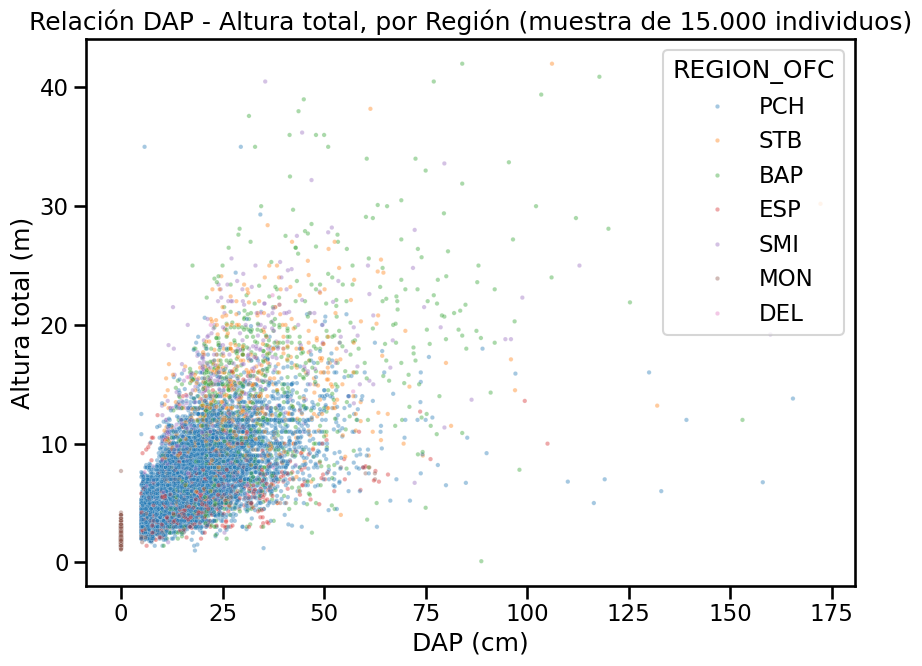

In [172]:
# Relación DAP vs Altura, coloreada por región
muestra = df_individuos_um.sample(n=15000, random_state=42)  # muestreo para que el scatter no sature

plt.figure(figsize=(9, 7))
sns.scatterplot(data=muestra, x='DAP_CM', y='ALTURA_TOTAL_M', hue='REGION_OFC',
                 palette='tab10', s=10, alpha=0.4, legend='brief')
plt.title('Relación DAP - Altura total, por Región (muestra de 15.000 individuos)')
plt.xlabel('DAP (cm)')
plt.ylabel('Altura total (m)')
plt.tight_layout()
plt.show()

El scatter coloreado por región presenta sobreplotting, al ser PCH la región con más individuos, tapa visualmente la nube de puntos de las demás regiones y no permite distinguir bien el patrón real.

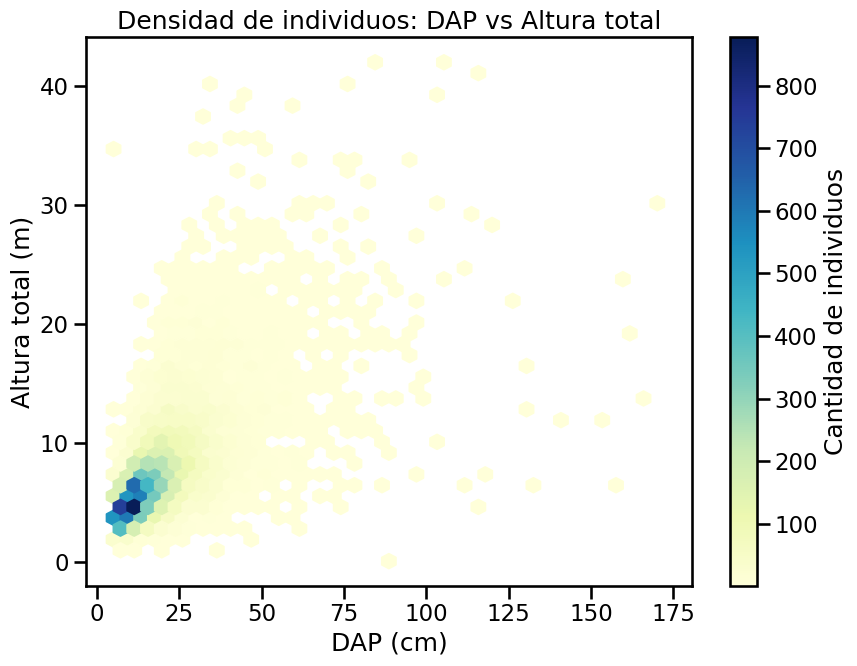

In [173]:
muestra_valida = muestra[(muestra['DAP_CM'] > 0) & (muestra['ALTURA_TOTAL_M'] > 0)]
plt.figure(figsize=(9, 7))
plt.hexbin(muestra_valida['DAP_CM'], muestra_valida['ALTURA_TOTAL_M'],
           gridsize=40, cmap='YlGnBu', mincnt=1)
plt.colorbar(label='Cantidad de individuos')
plt.title('Densidad de individuos: DAP vs Altura total')
plt.xlabel('DAP (cm)')
plt.ylabel('Altura total (m)')
plt.tight_layout()
plt.show()

Se aplica hexbin de densidad. Se observa que la enorme mayoría de los individuos se concentra en diámetros pequeños (DAP < 25 cm) y alturas bajas (< 10 m). La forma general creciente, con pendiente decreciente a medida que aumenta el DAP) es consistente con la relación alométrica esperada: la altura tiene un límite biológico por especie, mientras que el diámetro puede seguir creciendo con la edad del árbol.

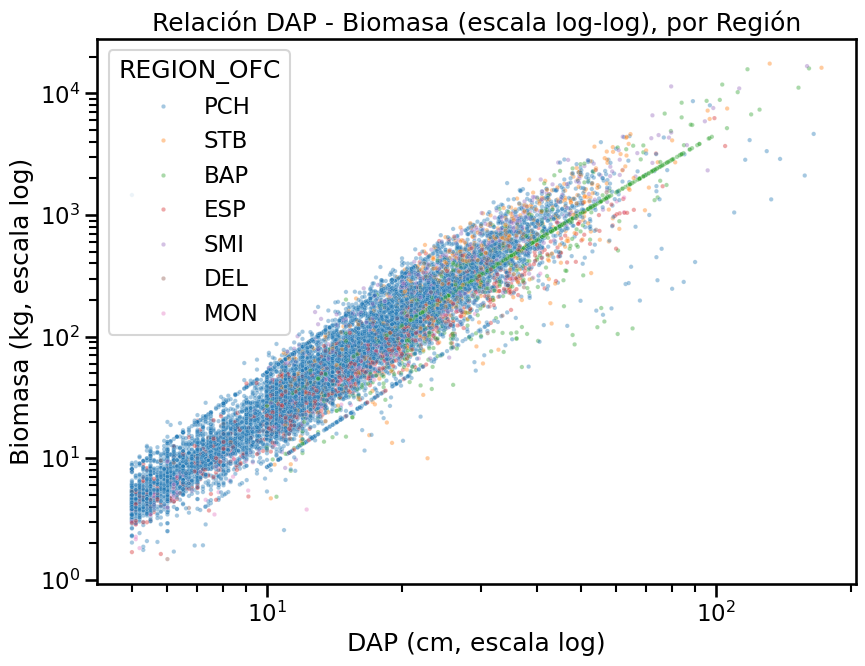

In [174]:
# Relación DAP vs Biomasa
plt.figure(figsize=(9, 7))
datos_biomasa = muestra[(muestra['DAP_CM'] > 0) & (muestra['BIOMASA_KG'] > 0)]
sns.scatterplot(data=datos_biomasa, x='DAP_CM', y='BIOMASA_KG', hue='REGION_OFC',
                 palette='tab10', s=10, alpha=0.4, legend='brief')
plt.xscale('log')
plt.yscale('log')
plt.title('Relación DAP - Biomasa (escala log-log), por Región')
plt.xlabel('DAP (cm, escala log)')
plt.ylabel('Biomasa (kg, escala log)')
plt.tight_layout()
plt.show()

Al igual que el caso anterior, el scatter por región queda dominado visualmente por PCH.

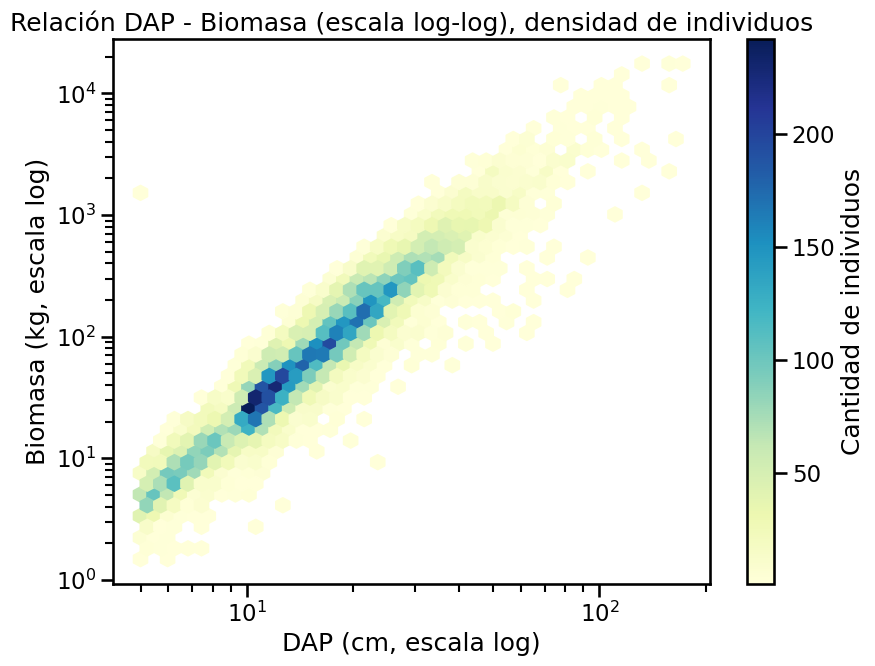

In [175]:
datos_biomasa_validos = muestra[(muestra['DAP_CM'] > 0) & (muestra['BIOMASA_KG'] > 0)]

plt.figure(figsize=(9, 7))
hb = plt.hexbin(
    datos_biomasa_validos['DAP_CM'], datos_biomasa_validos['BIOMASA_KG'],
    gridsize=40, cmap='YlGnBu', mincnt=1,
    xscale='log', yscale='log'
)
plt.colorbar(hb, label='Cantidad de individuos')
plt.title('Relación DAP - Biomasa (escala log-log), densidad de individuos')
plt.xlabel('DAP (cm, escala log)')
plt.ylabel('Biomasa (kg, escala log)')
plt.tight_layout()
plt.show()

In [176]:
#Correlación
datos_reg = muestra[(muestra['DAP_CM'] > 0) & (muestra['BIOMASA_KG'] > 0)]
log_dap = np.log(datos_reg['DAP_CM'])
log_biomasa = np.log(datos_reg['BIOMASA_KG'])

slope, intercept, r, p, se = stats.linregress(log_dap, log_biomasa)
a = np.exp(intercept)
print(f"Biomasa ≈ {a:.3f} · DAP^{slope:.3f}   (R² = {r**2:.3f})")

Biomasa ≈ 0.088 · DAP^2.438   (R² = 0.913)


El hexbin en escala logaritmica muestra un patrón en cual los puntos se alinean de forma casi lineal en el espacio log-log, lo que indica una relación de tipo potencial (Biomasa ≈ a·DAP^b). El ajuste log-log da un exponente b=2.44 con R^2=0.91, confirmando la relación alométrica observada visualmente.

La concentración de individuos (zona azul oscuro) se da en diámetros de 10-20 cm con biomasas de 20-100 kg, mientras que hacia los extremos superiores del diámetro la nube se dispersa (color más claro) por haber menos individuos grandes en la muestra, ya que los árboles de gran porte son naturalmente menos frecuentes que los juveniles en cualquier bosque con buena regeneración.


En conjunto con estos gráficos indica que el dataset es consistente con el comportamiento biológico/dasométrico esperado. A partir de esta base, posteriormente se puede profundizar en modelos que estimen biomasa o altura a partir del diámetro por región o especie.

### 1.10. Estructura diamétrica del bosque

La distribución de individuos por clase diamétrica es uno de los indicadores  de "salud" o estado de un bosque nativo: una distribución en forma de J invertida (muchos individuos jóvenes/pequeños, decreciendo gradualmente hacia los diámetros grandes) indica buena regeneración natural y sostenibilidad estructural. Una distribución achatada o con "faltantes" en las clases jóvenes puede indicar sobreexplotación o falta de regeneración.

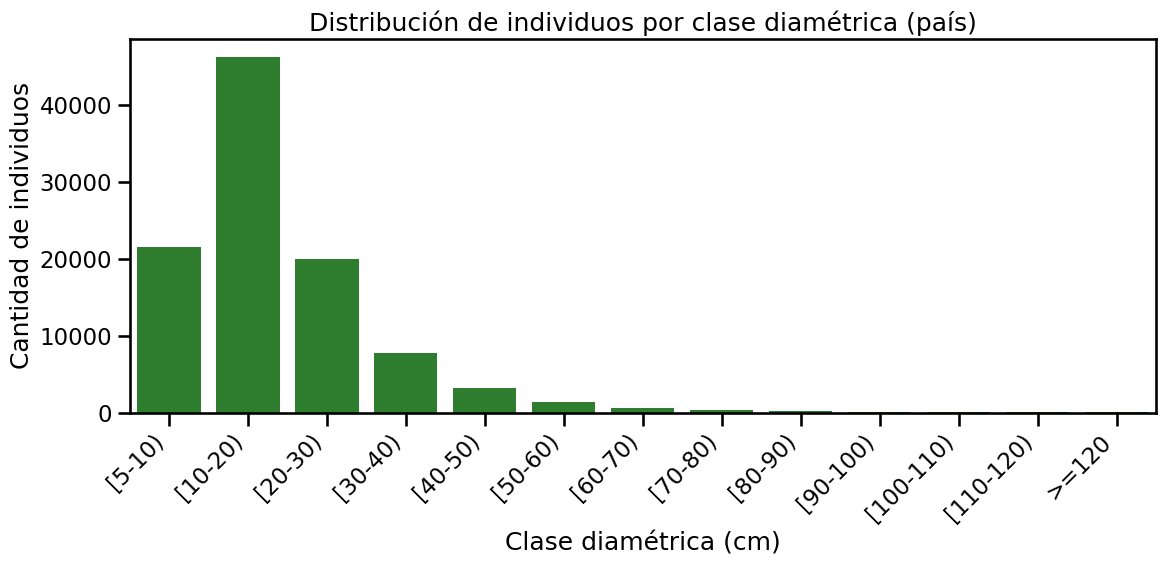

In [177]:
# Orden natural de las clases diamétricas
orden_clases = ['[5-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)', '[50-60)',
                 '[60-70)', '[70-80)', '[80-90)', '[90-100)', '[100-110)', '[110-120)', '>=120']

plt.figure(figsize=(12, 6))
sns.countplot(data=df_ind, x='CLASE_DIAM', order=orden_clases, color='forestgreen')
plt.title('Distribución de individuos por clase diamétrica (país)')
plt.xlabel('Clase diamétrica (cm)')
plt.ylabel('Cantidad de individuos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

La distribución a nivel país tiene la forma de J invertida esperada en un bosque con buena regeneración natural: la clase `[10-20)` concentra la mayor cantidad de individuos (46.000), seguida por `[5-10)` y `[20-30)`, y la cantidad decae de forma marcada hacia las clases diamétricas mayores, con poca presencia de individuos por encima de los 80 cm de DAP.

Esto es un buen indicador de sostenibilidad estructural a nivel nacional: hay abundante reposición de individuos jóvenes respecto de los adultos.

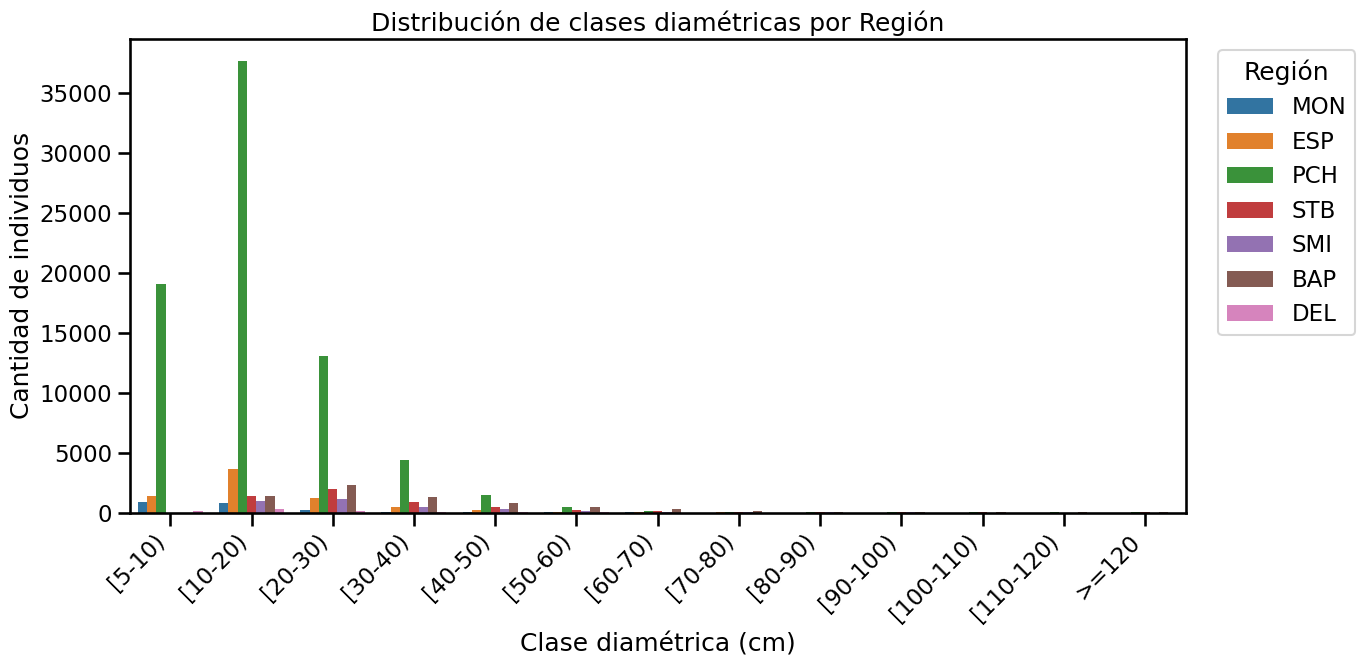

In [178]:
# Misma distribución, discriminada por región (para ver si el patrón se sostiene en todas)
plt.figure(figsize=(14, 7))
sns.countplot(data=df_ind, x='CLASE_DIAM', hue='REGION_OFC', order=orden_clases)
plt.title('Distribución de clases diamétricas por Región')
plt.xlabel('Clase diamétrica (cm)')
plt.ylabel('Cantidad de individuos')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Región', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()



Al desagregar por región, se observa que este patrón está dominado por el Parque Chaqueño (PCH), que por su gran tamaño muestral concentra la mayoría de los individuos en casi todas las clases.

El patrón de J invertida se replica de forma consistente en todas las regiones (cada una decrece de forma similar de menor a mayor clase diamétrica), lo que sugiere que la buena regeneración es un patrón generalizado en el bosque nativo relevado.

No se observan "huecos" o faltantes anómalos en clases intermedias que indicarían sobreexplotación selectiva.

### 1.11. Análisis por especie

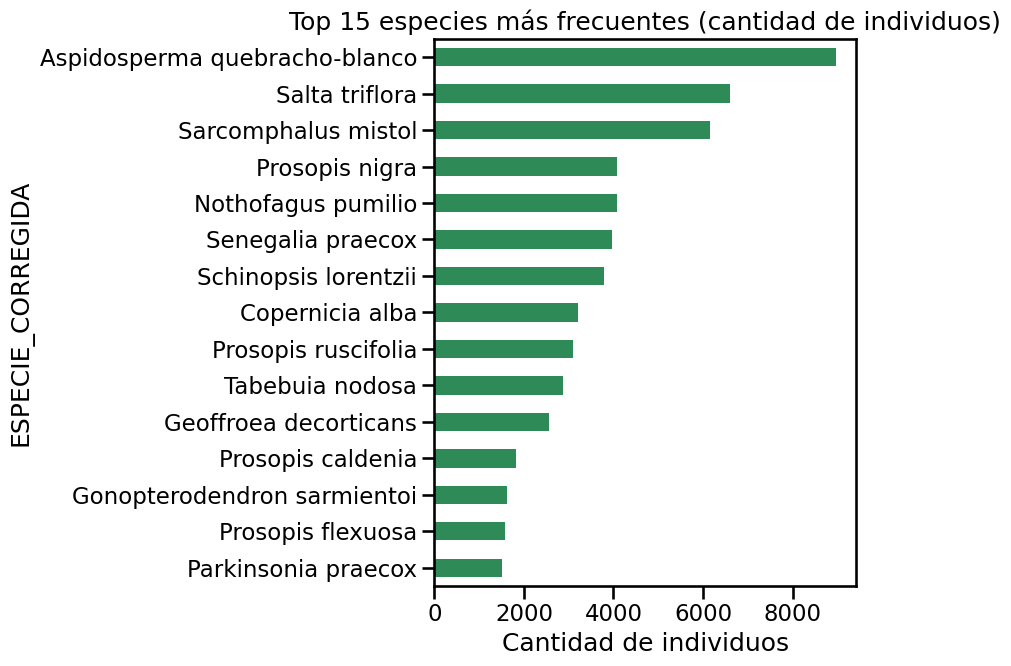

In [179]:
# Especies más frecuentes (por cantidad de individuos)
top_especies_n = df_ind['ESPECIE_CORREGIDA'].value_counts().head(15)

plt.figure(figsize=(9, 7))
top_especies_n.sort_values().plot(kind='barh', color='seagreen')
plt.title('Top 15 especies más frecuentes (cantidad de individuos)')
plt.xlabel('Cantidad de individuos')
plt.tight_layout()
plt.show()

### 1.12. Comparación de variables estructurales por región

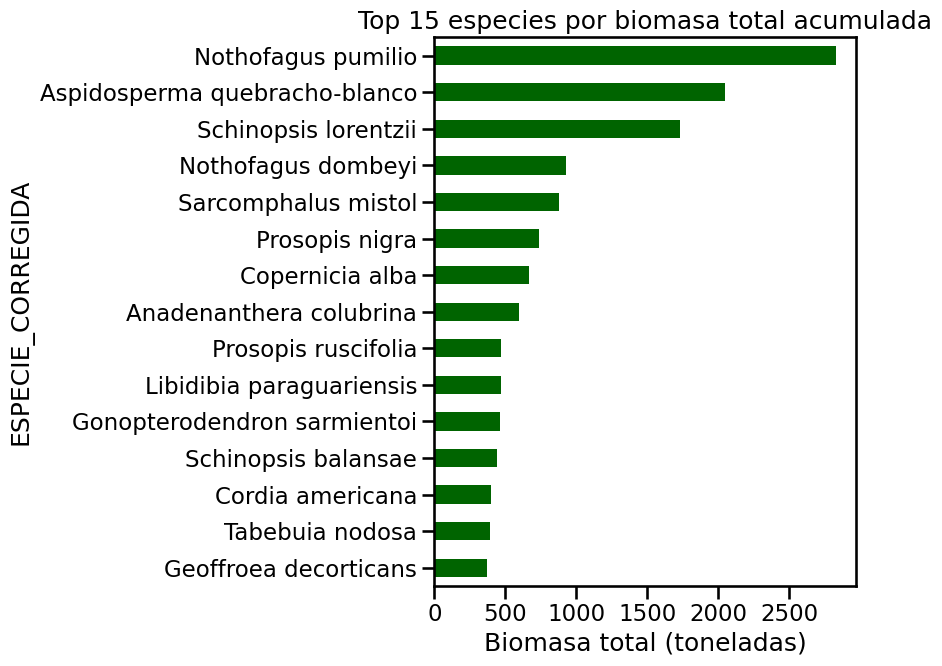

In [180]:
# Especies que más biomasa acumulan (no necesariamente las más numerosas)
top_especies_biomasa = df_ind.groupby('ESPECIE_CORREGIDA')['BIOMASA_KG'].sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 7))
(top_especies_biomasa / 1000).sort_values().plot(kind='barh', color='darkgreen')
plt.title('Top 15 especies por biomasa total acumulada')
plt.xlabel('Biomasa total (toneladas)')
plt.tight_layout()
plt.show()

Los dos rankings no coinciden, y esa diferencia es informativa.

*Aspidosperma quebracho-blanco* (quebracho blanco) es la especie más numerosa en cantidad de individuos (9.000) y también aparece en el top de biomasa, lo cual es consistente porque es una especie de porte grande y muy abundante en el Parque Chaqueño.

En cambio, *Nothofagus pumilio* (lenga) lidera el ranking de biomasa total acumulada, porque es un árbol de gran porte (Bosque Andino Patagónico), donde cada individuo aporta mucha más biomasa que un individuo típico del Parque Chaqueño. Lo mismo ocurre con *Schinopsis lorentzii* (quebracho colorado) y *Nothofagus dombeyi* (coihue), que no están entre las más numerosas pero sí entre las de mayor aporte de biomasa.

A priori, se puede concluir que la biomasa forestal no está determinada solo por la abundancia de individuos, sino fuertemente por el porte/tamaño típico de cada especie.

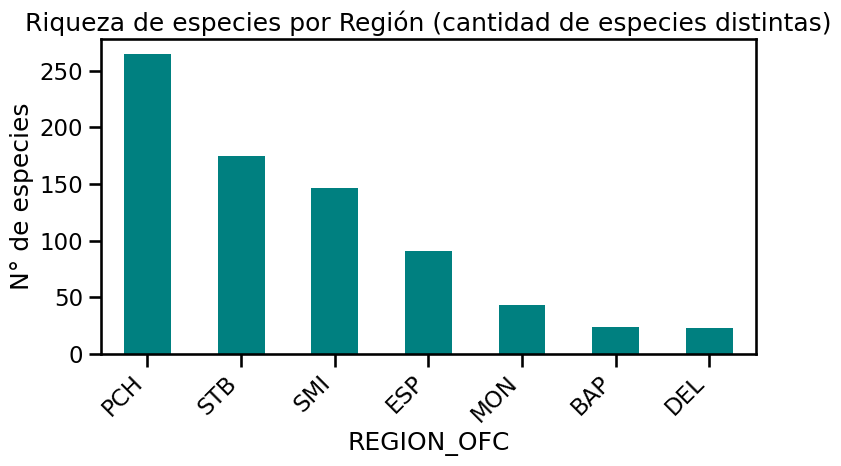

In [181]:
# Riqueza de especies por región (cuántas especies distintas hay en cada región)
riqueza_region = df_ind.groupby('REGION_OFC')['ESPECIE_CORREGIDA'].nunique().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
riqueza_region.plot(kind='bar', color='teal')
plt.title('Riqueza de especies por Región (cantidad de especies distintas)')
plt.ylabel('N° de especies')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

El Parque Chaqueño (PCH) no solo es la región con más individuos muestreados, sino también la de mayor riqueza de especies (265 especies distintas). Le siguen Espinal Serrano y Bosque Tucumano-Boliviano (STB) y Selva Misionera (SMI) con un tercio de esa riqueza aproximadamente.

En el otro extremo, Bosque Andino Patagónico (BAP) y Delta e Islas (DEL) muestran muy baja riqueza (25 especies), consistente con ser biomas dominados por pocas especies muy características (ej. *Nothofagus* en la Patagonia) en vez de ecosistemas de alta diversidad florística.


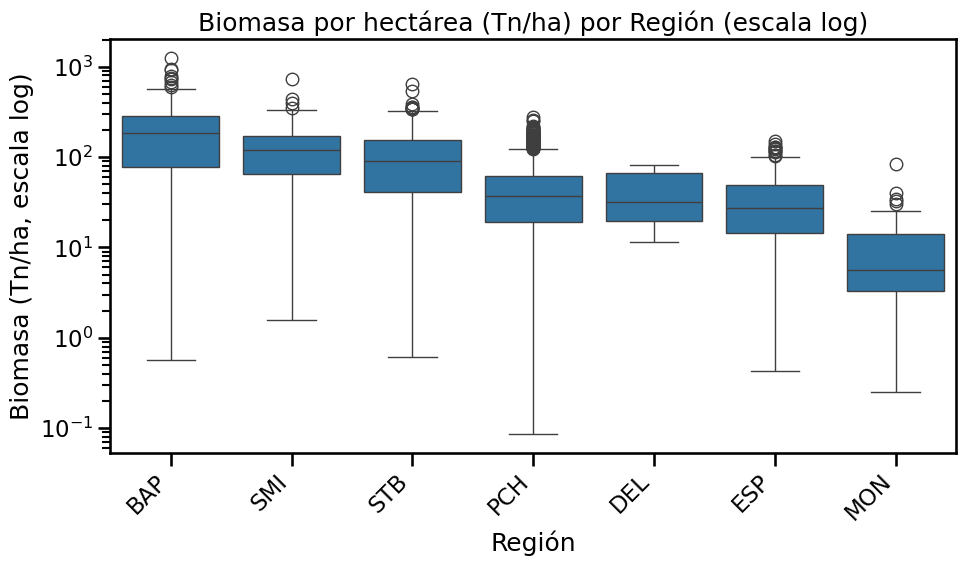

In [182]:
# Biomasa por hectárea, comparada entre regiones
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_um_2022, x='REGION_OFC', y='BIOMASA_TN_HA',
            order=df_um_2022.groupby('REGION_OFC')['BIOMASA_TN_HA'].median().sort_values(ascending=False).index)
plt.yscale('log')
plt.title('Biomasa por hectárea (Tn/ha) por Región (escala log)')
plt.xlabel('Región')
plt.ylabel('Biomasa (Tn/ha, escala log)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Aparece un contraste interesante con el gráfico de riqueza: BAP, la región con menor riqueza de especies, es la que tiene mayor biomasa por hectárea (mediana 180 Tn/ha), seguida por Selva Misionera (SMI) y STB.

En el otro extremo, Monte (MON) tiene la biomasa por hectárea más baja (mediana 5 Tn/ha) y también la menor dispersión.

Esto indican que los bosques patagónicos y de selva (BAP, SMI) están compuestos por árboles de gran porte y alta densidad de madera por unidad de superficie, mientras que Monte es un bioma árido con vegetación xerófila de menor biomasa por naturaleza, aunque cubra grandes extensiones. Es decir, no hay relación directa entre diversidad de especies y biomasa acumulada.

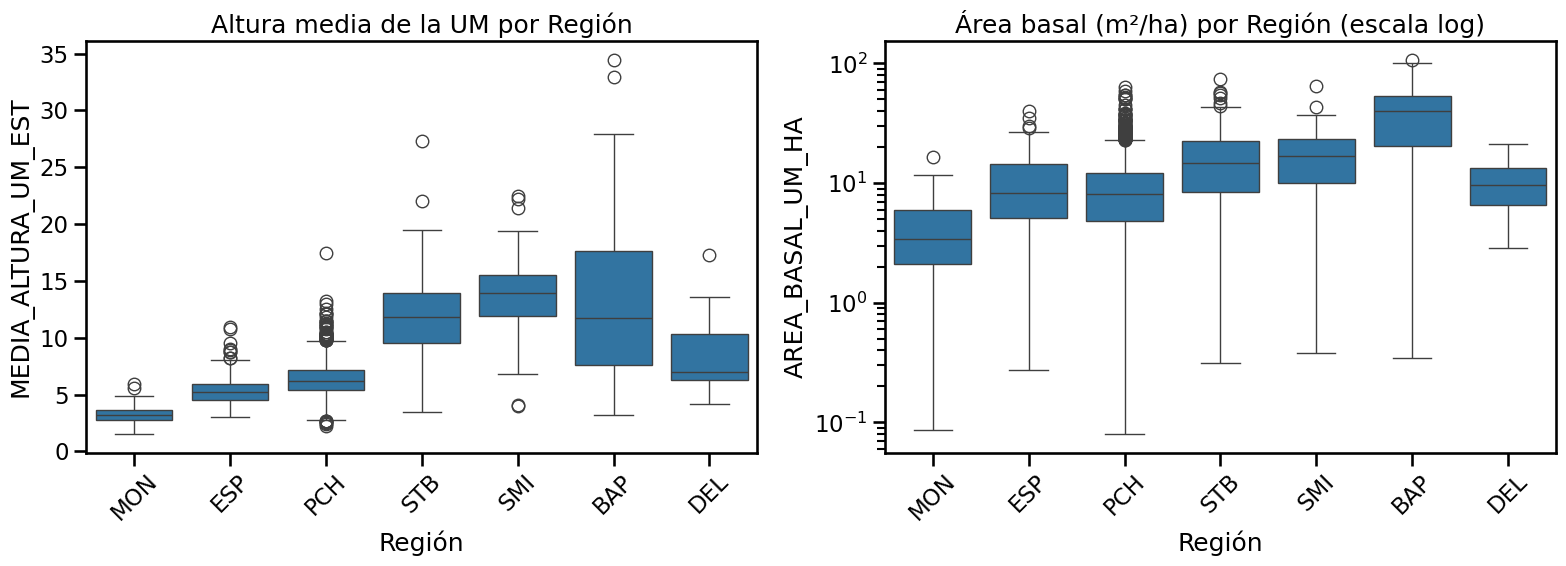

In [183]:
# Altura media y área basal por región, en un mismo panel
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=df_um_2022, x='REGION_OFC', y='MEDIA_ALTURA_UM_EST', ax=axes[0])
axes[0].set_title('Altura media de la UM por Región')
axes[0].set_xlabel('Región')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(data=df_um_2022, x='REGION_OFC', y='AREA_BASAL_UM_HA', ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_title('Área basal (m²/ha) por Región (escala log)')
axes[1].set_xlabel('Región')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Se observa que el Monte (MON) tiene la menor altura media (3-4 m) y menor área basal, coherente con ser vegetación arbustiva/xerófila de bajo porte. BAP y Selva Misionera (SMI) muestran las alturas medias más altas (12-14 m de mediana, con UM que llegan a superar los 30 m) y, junto con STB, también el mayor área basal por hectárea.

PCH, tiene alturas y área basal bajas, lo cual es consistente con ser un bosque xerófilo denso mayormente en clases diamétricas chicas.


**Síntesis:**

Cruzando los cuatro gráficos anteriores, sedestaca un patrón  de especialización ecológica por región, PCH se destaca por cantidad y diversidad de individuos/especies pero con bajo porte individual; BAP y SMI, en cambio, tienen pocas especies pero de gran porte, concentrando la mayor biomasa y altura por hectárea; y MON representa el extremo opuesto en casi todas las variables estructurales (menor altura, menor área basal, menor biomasa), reflejando su condición de bioma árido.

## Conclusiones finales — TP1

**Sobre las fuentes de datos:** el INBN2 se compone de dos tablas complementarias: una a nivel de parcela (unidad de muestreo) y otra a nivel de individuo, vinculadas por `UM_ID_UM`.

El chequeo de consistencia (cantidad de individuos recalculada vs. `CANTIDAD_IND_VIVOS_UM`) mostró coincidencia  en el 91.6% de las UM, validando el cruce entre tablas para el resto del análisis. Se identificó  que la versión 2022 de la tabla general no es simplemente la 2021 con columnas nuevas, sino una revisión que recalculó buena parte de las variables compartidas, por lo que se adoptó como fuente única de verdad. La curación aplicada en este TP1 es exploratoria, las decisiones de imputación definitiva o tratamiento estadístico de estas variables se abordarán en el TP2.

**Sobre la calidad de los datos:** la gran mayoría de los valores faltantes  tienen una explicación estructural documentada (no aplica, variable incorporada al protocolo después de 2018, o medición alternativa para formas de crecimiento distintas) y no requirieron imputación ni eliminación de filas o columnas. Se corrigió  un error propio de diagnóstico (falso positivo de duplicados por clave mal definida) y se detectó que las coordenadas de la tabla general están en una escala inválida, resuelto usando las coordenadas de la tabla de individuos.

**Sobre la estructura del bosque:** la distribución de clases diamétricas tiene la forma de J invertida esperada en un bosque con buena regeneración natural, patrón que se replica de forma consistente en todas las regiones relevadas. Las relaciones DAP-altura y DAP-biomasa son consistentes con el comportamiento alométrico esperado en dasometría forestal (relación potencial en escala log-log), lo que valida la coherencia interna del dataset.

**Sobre los patrones regionales:** emergió un patrón claro de especialización ecológica. El Parque Chaqueño concentra la mayor cantidad de individuos y la mayor riqueza de especies (265), pero con bajo porte individual. El Bosque Andino Patagónico y la Selva Misionera, en cambio, tienen baja riqueza de especies pero son las regiones con mayor biomasa, altura y área basal por hectárea, lideradas por especies de gran porte como *Nothofagus pumilio*. Monte representa el extremo opuesto en casi todas las variables estructurales, consistente con su condición de bioma árido.

Esto muestra que diversidad de especies y biomasa acumulada son dimensiones independientes del estado del bosque, y que ambas deben considerarse para una evaluación integral.

**Próximos pasos:** este análisis sienta las bases para TP2 (curación más profunda / detección de outliers) y TP3 (modelos que expliquen biomasa o clasifiquen tipos de bosque a partir de las variables estructurales relevadas).